# Kalman Filter Price-Target Model — Fused MvGRW Panel

**Notebook form of `pymc_kalman_filter_pt.py`**, aligned with
`probabilistic_ml_model/pymc_models/KalmanFilterModel.py`.

The cross-sectional spine is the **fused MvGRW panel model**
(`build_fused_kalman_pt_model`):

- **Model B spine** — a diagonal (NUTS-safe) Multivariate Gaussian Random Walk over the
  `(isin, time, y_series)` response tensor with a cross-sectional baseline `mu_isin`.
- **Model A refinement** — the risk-aware `expected_return → risk_adj_return`
  latent (with a non-centred logit-normal `achieve_prob`) *is* the GRW baseline
  `mu_isin`, and the heteroscedastic scale `sigma_isin = sigma_base · (1 + cv) / √n`
  replaces the cv-free form. The risk adjustment is keyed on **systematic risk**
  (`feat_avg_beta`, the NULL-aware mean of `beta_{1y,2y,5y}`) rather than analyst
  conviction — replacing the earlier expected-volatility (`feat_vol_*`) penalty.

The workflow has two halves:

| Sections    | Scope                                                                                                                        |
|-------------|------------------------------------------------------------------------------------------------------------------------------|
| **§1–§10**  | Fused cross-sectional panel — one row per ISIN from `pml.mv_pymc_kalman_pt`                                                  |
| **§11–§14** | Single-security / cohort time-series — the `KalmanFilterPriceTarget` GRW filter on the embedded `*_ago` price-target history |

**Schema is the single source of truth (`pml` schema):** MV `pml.mv_pymc_kalman_pt`,
catalogue `pml.vw_pymc_feature_catalogue WHERE model_target = 'kalman_pt'`, coords
`pml.vw_pml_df_coords`.

> **Design note.** This notebook *orchestrates* the functions defined in
> `pymc_kalman_filter_pt.py`; it does not re-implement them. The module stays the
> single source of truth, and each section here calls into it and keeps the returned
> artifact at the top level so you can inspect it interactively.

## §0 — Environment & imports

`PYTENSOR_FLAGS` must be set **before** PyTensor/PyMC are first imported. On Windows
the flag parser strips backslashes from the `cxx` path (`C:\msys64\...` →
`C:msys64...`, a nonexistent compiler that hangs the *"Compiling new CVM"* step), so we
emit the g++ path with **forward slashes**, which survive the parser. If you launched
this kernel after `. .\set_env.ps1`, the existing flag is respected; otherwise we
auto-detect g++ and set a safe value here.

In [1]:
import os
from pathlib import Path

# Set a parser-safe PYTENSOR_FLAGS *before* importing pymc/pytensor (idempotent).
if "cxx=" not in os.environ.get("PYTENSOR_FLAGS", ""):
    _gxx = next(
        (p for p in (r"C:/msys64/ucrt64/bin/g++.exe", r"C:/msys64/mingw64/bin/g++.exe")
         if Path(p).exists()),
        "",  # empty cxx -> pure-Python / numba path (nutpie still works)
    )
    os.environ["PYTENSOR_FLAGS"] = f"floatX=float64,cxx={_gxx}"

import pytensor

print("PyTensor", pytensor.__version__, "| cxx =", repr(pytensor.config.cxx),
      "| exists:", bool(pytensor.config.cxx) and Path(pytensor.config.cxx).exists())

PyTensor 3.0.7 | cxx = 'C:msys64ucrt64bing++.exe' | exists: False


C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\pytensor\configparser.py:309: UserWarning: PyTensor does not recognise this flag: device
  warnings.warn(f"PyTensor does not recognise this flag: {key}")


In [2]:
import logging

import pymc as pm
import numpy as np
import arviz_plots as azp
from xarray import DataTree
from sqlalchemy import create_engine

# Section functions live in the module (single source of truth) — import, don't re-define.
import pymc_kalman_filter_pt as kf
from pymc_kalman_filter_pt import (
    RANDOM_SEED,
    setup_plotting, resolve_db_url,
    load_kalman_df, load_feature_catalogue, resolve_feature_roles,
    run_eda, map_state_space_features, prepare_kalman_panel_inputs,
    build_panel_model, run_prior_predictive, sample_posterior, run_posterior_predictive,
    run_diagnostics, summarize_panel_screen, export_analytics,
    run_single_isin_filter, run_single_isin_stochastic_vol,
    run_mingled_cohort_filter, run_mingled_cohort_stochastic_vol,
    run_granular_forest, run_granular_further_views,
    run_summary, run_recommendations,
    present_group_effects,
)

logging.basicConfig(level=os.environ.get("LOG_LEVEL", "INFO"))
setup_plotting()
engine = create_engine(resolve_db_url())
print("Setup complete — RANDOM_SEED =", RANDOM_SEED, "| orchestrating:", kf.__file__)

Setup complete — RANDOM_SEED = 42 | orchestrating: C:\Users\markm\PML_Finance_Project\pymc_kalman_filter_pt.py


## §1 — Data load & feature-role resolution

- `load_kalman_df` — cross-sectional `pml.mv_pymc_kalman_pt` snapshot (one row per ISIN,
  filtered to `observed_pt IS NOT NULL` and next earnings in the modelling horizon).
- `load_feature_catalogue` — the `kalman_pt` rows of `pml.vw_pymc_feature_catalogue`.
- `resolve_feature_roles` — groups columns by `pymc_role` (catalogue SSOT, MV-schema
  fallback): predictors, coords, responses, classification coords, fiscal-calendar and
  day-count columns.

In [3]:
kalman_df = load_kalman_df(engine)
feature_catalogue = load_feature_catalogue(engine)
roles = resolve_feature_roles(kalman_df, feature_catalogue)
kalman_df.head()

INFO:pymc_kalman_filter_pt:Loaded kalman_df: (6233, 94)
INFO:pymc_kalman_filter_pt:Loaded feature_catalogue: (112, 8)


,pymc_role,feature_role,n_columns,n_present
0,constant_data,count,1,1
1,constant_data,historical,7,7
2,coord,categorical,11,11
3,coord,date,6,6
4,derived_input,historical,21,0
5,derived_input,predictor,3,3
6,mutable_predictor,predictor,21,21
7,mutable_predictor,target,6,6
8,observed,historical,32,32
9,observed,target,4,4


#predictors     : 27 -> ['days_since_last_report', 'days_to_expected_report', 'days_to_fy_end', 'days_to_next_earnings', 'days_to_next_fy_end', 'days_to_next_report', 'feat_avg_beta', 'feat_coverage_drift', 'feat_implied_upside', 'feat_price_drift', 'feat_pt_drift', 'feat_pt_high_drift', 'feat_pt_low_drift', 'feat_pt_median_drift', 'feat_pt_noise_drift', 'feat_pt_range_norm', 'feat_vol_1m', 'feat_vol_1y', 'feat_vol_3m', 'feat_vol_6m', 'last_price', 'feat_pt_noise_sigma', 'feat_total_return_10y', 'feat_total_return_5y', 'feat_total_return_ytd', 'feat_tr_cagr_10y', 'feat_tr_cagr_3y']
#response       : 36 -> ['price_target_1m_ago', 'price_target_1w_ago', 'price_target_1y_ago', 'price_target_3m_ago', 'price_target_6m_ago', 'price_target_high_1m_ago', 'price_target_high_1w_ago', 'price_target_high_1y_ago', 'price_target_high_3m_ago', 'price_target_high_6m_ago', 'price_target_high_mtd_ago', 'price_target_high_qtd_ago', 'price_target_high_ytd_ago', 'price_target_low_1m_ago', 'price_target_low

,isin,ticker,name,region,country,trading_country,exchange,unit,style_class,size_class,...,feat_vol_1y,beta_1y,beta_2y,beta_5y,feat_avg_beta,feat_total_return_ytd,feat_total_return_5y,feat_total_return_10y,feat_tr_cagr_3y,feat_tr_cagr_10y
0,US67066G1040,NVDA,NVIDIA Corporation,United States and Canada,US,US,NasdaqGS,USD,Growth,Large Cap,...,35.29,1.39,2.04,2.20,1.876667,0.1311,10.3430,182.9531,0.7012,0.6838
1,IE000GID8VI0,GHRS,GH Research PLC,Europe,IE,US,NasdaqGM,USD,Core,Small Cap,...,78.47,1.89,1.26,1.31,1.486667,0.7512,NaN,NaN,0.2441,NaN
2,US36266G1076,GEHC,GE HealthCare Technologies Inc.,United States and Canada,US,US,NasdaqGS,USD,Core,Mid Cap,...,32.45,1.28,1.23,0.86,1.123333,-0.2484,NaN,NaN,-0.0765,NaN
3,US0420682058,ARM,Arm Holdings plc,Europe,GB,US,NasdaqGS,USD,Growth,Large Cap,...,69.75,1.50,2.50,3.79,2.596667,3.0203,NaN,NaN,NaN,NaN
4,US02079K3059,GOOGL,Alphabet Inc.,United States and Canada,US,US,NasdaqGS,USD,Core,Large Cap,...,29.20,1.66,1.16,1.24,1.353333,0.1773,2.0913,9.5444,0.4417,0.2654


## §2 — Exploratory data analysis

`run_eda` renders the EDA panels through a state-space lens: drift features → the
state-transition mean (`beta` slopes), noise wideners → the measurement-noise scale
`sigma_obs`. Includes missingness overview, implied-upside ridges by industry,
coord cardinality, the winsorised `feat_*` distributional summary, the observation-noise
widener marginals, the feature collinearity heatmap, and per-group implied-upside
forests (an EDA preview of the §5 group effects).

> Skip this cell for a faster run — nothing downstream depends on it.

kalman_df shape: (6233, 94)


,dtype,n_missing,pct_missing,n_unique
feat_tr_cagr_10y,float64,1908,30.6,2775
feat_total_return_10y,float64,1908,30.6,4200
feat_total_return_5y,float64,781,12.5,5079
feat_tr_cagr_3y,float64,414,6.6,4342
beta_5y,float64,396,6.4,382
beta_2y,float64,255,4.1,362
beta_1y,float64,255,4.1,490
feat_avg_beta,float64,255,4.1,1423
price_target_low_1y_ago,float64,195,3.1,2128
price_target_num_1y_ago,float64,195,3.1,53


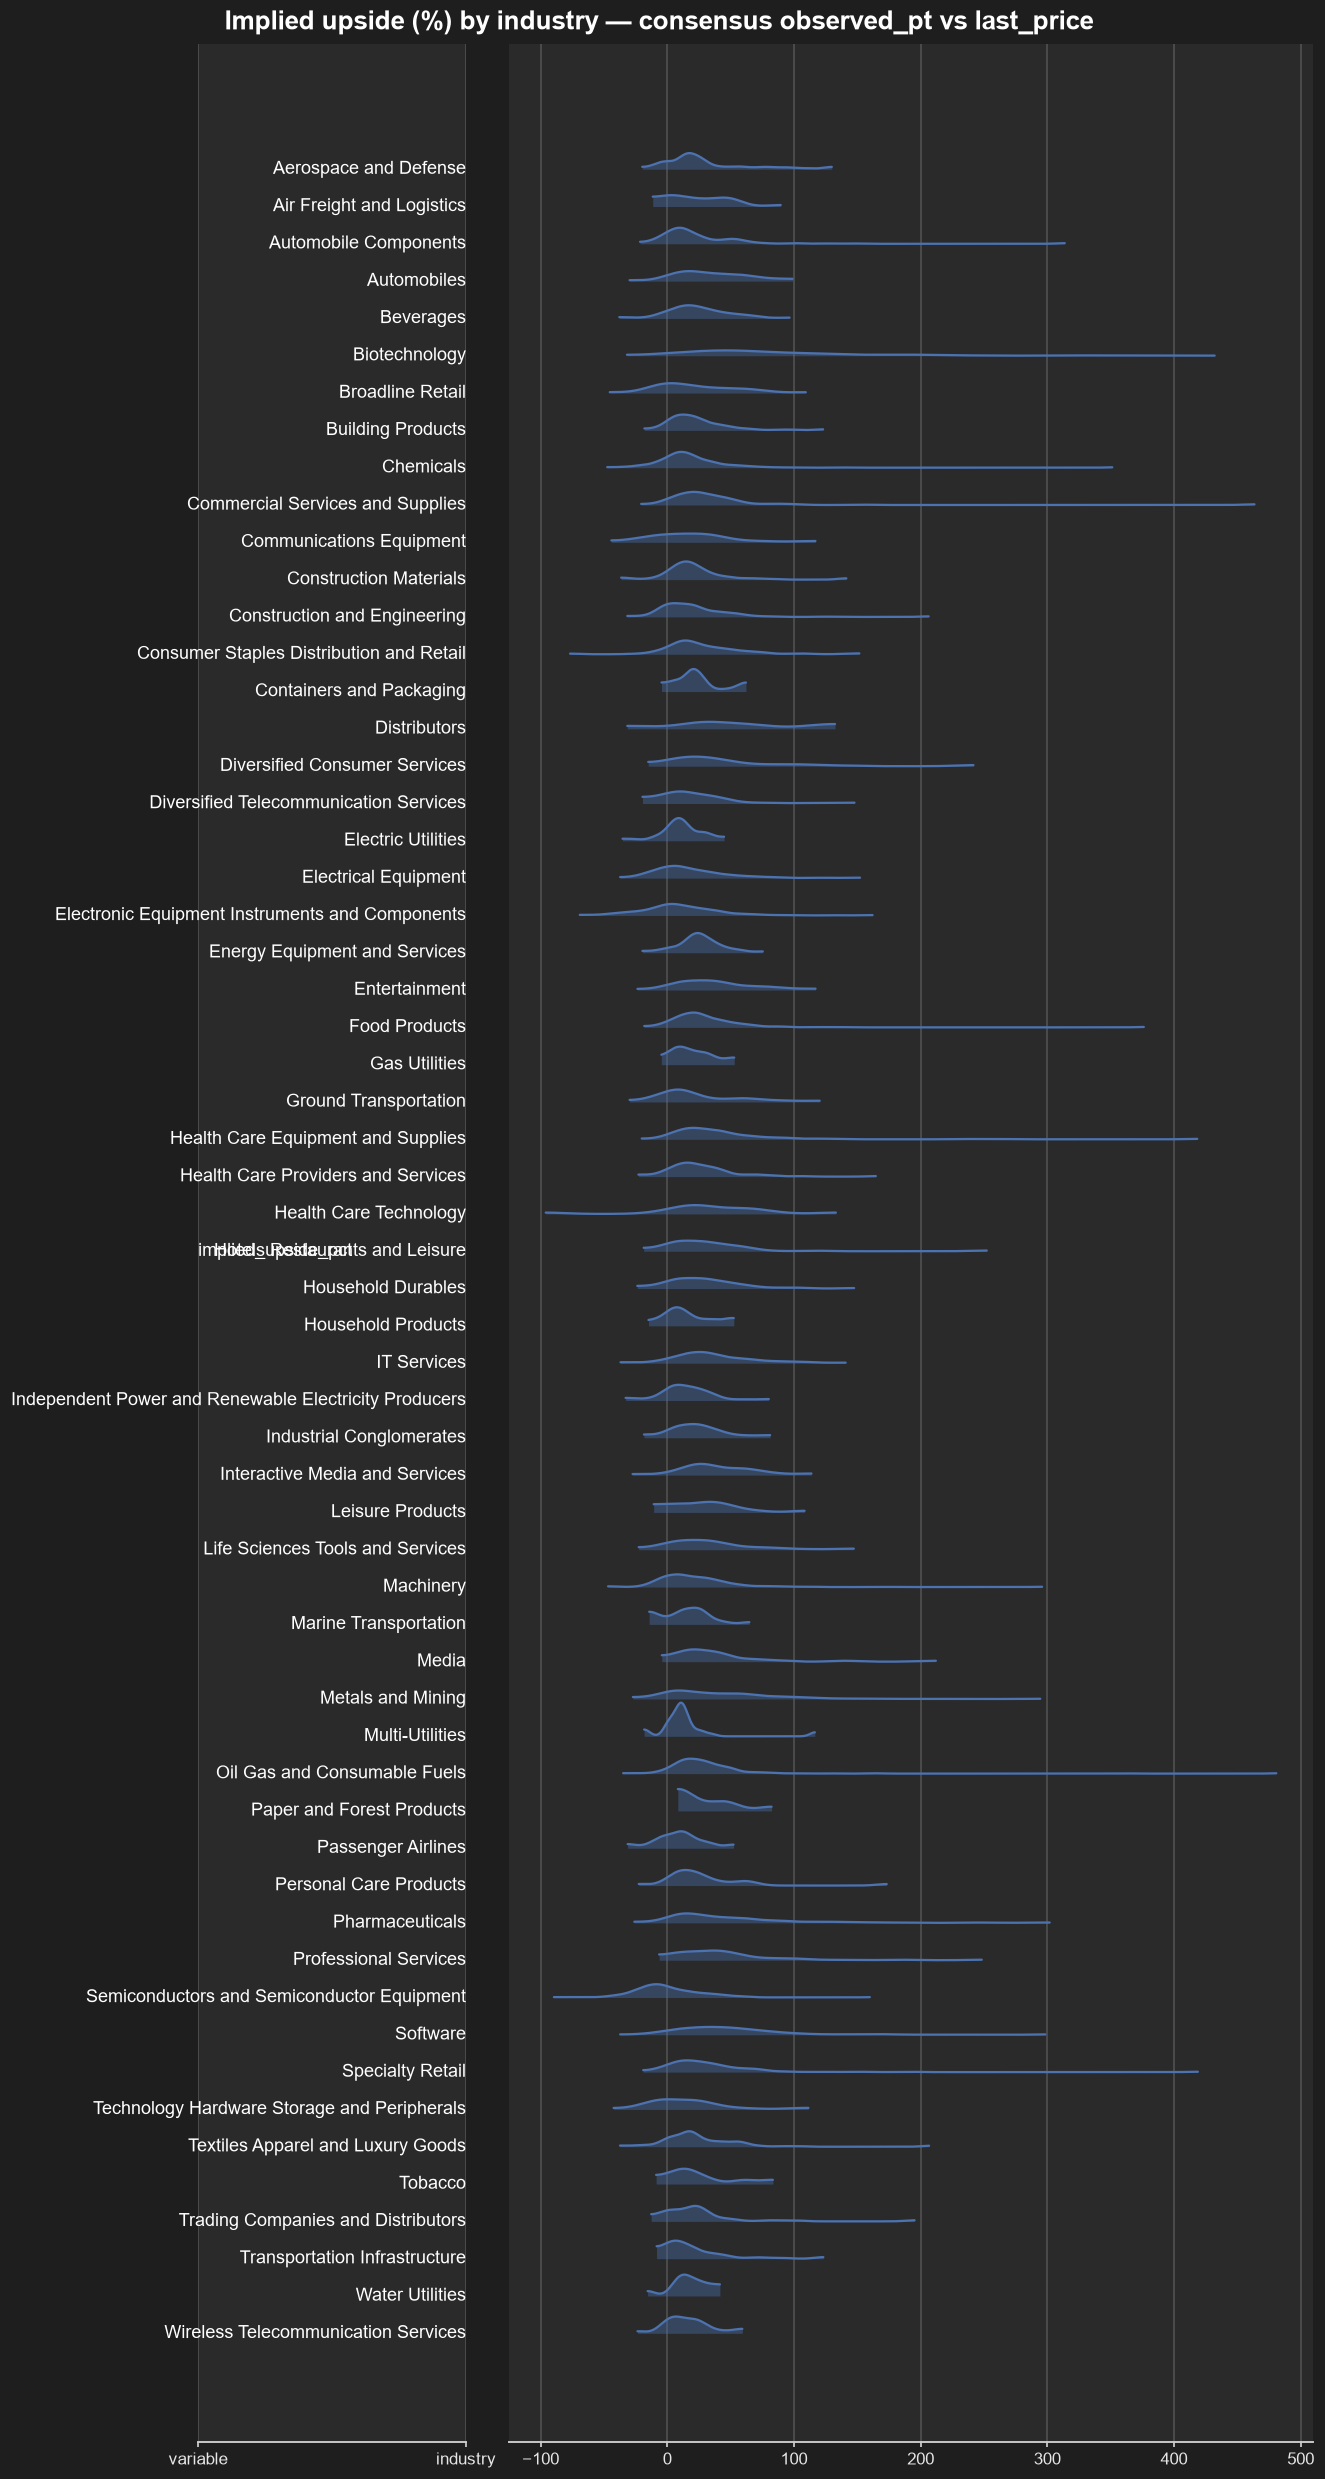

count    6233.000000
mean       29.498648
std        40.623488
min       -96.209386
25%         7.251099
50%        21.389155
75%        41.788643
max       481.250000
Name: upside_pct, dtype: float64

country            81
exchange           80
trading_country    63
industry           59
unit               47
sector              9
region              5
style_class         3
size_class          3
dtype: int64

Distributional summary (winsorised 1/99 pct) for 18 feat_* columns:


,mean,sd,eti89_lb,eti89_ub
feat_pt_drift,0.0498,0.1083,-0.0734,0.2532
feat_price_drift,0.0606,0.1329,-0.0894,0.3103
feat_pt_high_drift,0.0544,0.1167,-0.0667,0.2736
feat_pt_low_drift,0.0500,0.1155,-0.0864,0.2624
feat_pt_median_drift,0.0526,0.1135,-0.0750,0.2650
feat_coverage_drift,0.0307,0.0829,-0.0500,0.2000
feat_pt_noise_drift,0.1523,0.3485,-0.1226,0.7563
feat_total_return_ytd,0.1429,0.4663,-0.3402,0.9635
feat_total_return_5y,1.1973,2.9290,-0.7499,5.7973
feat_total_return_10y,4.7534,10.4145,-0.5307,19.3672


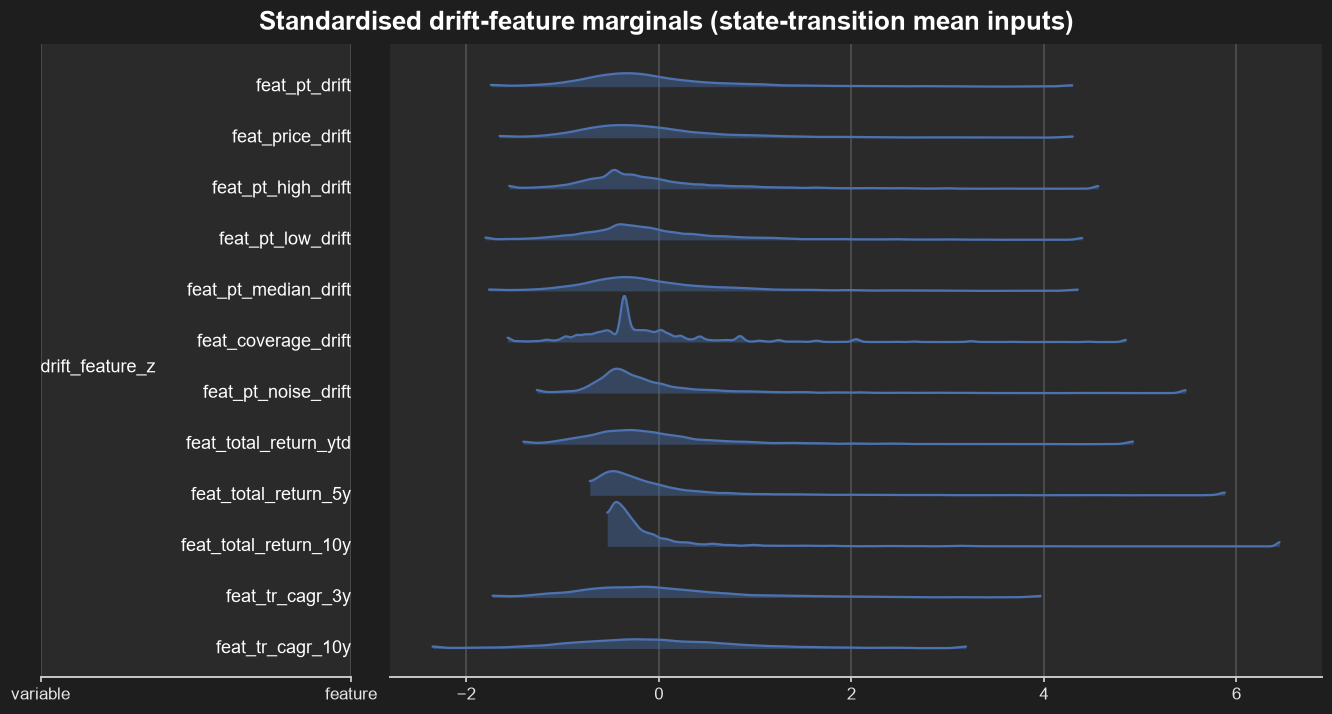

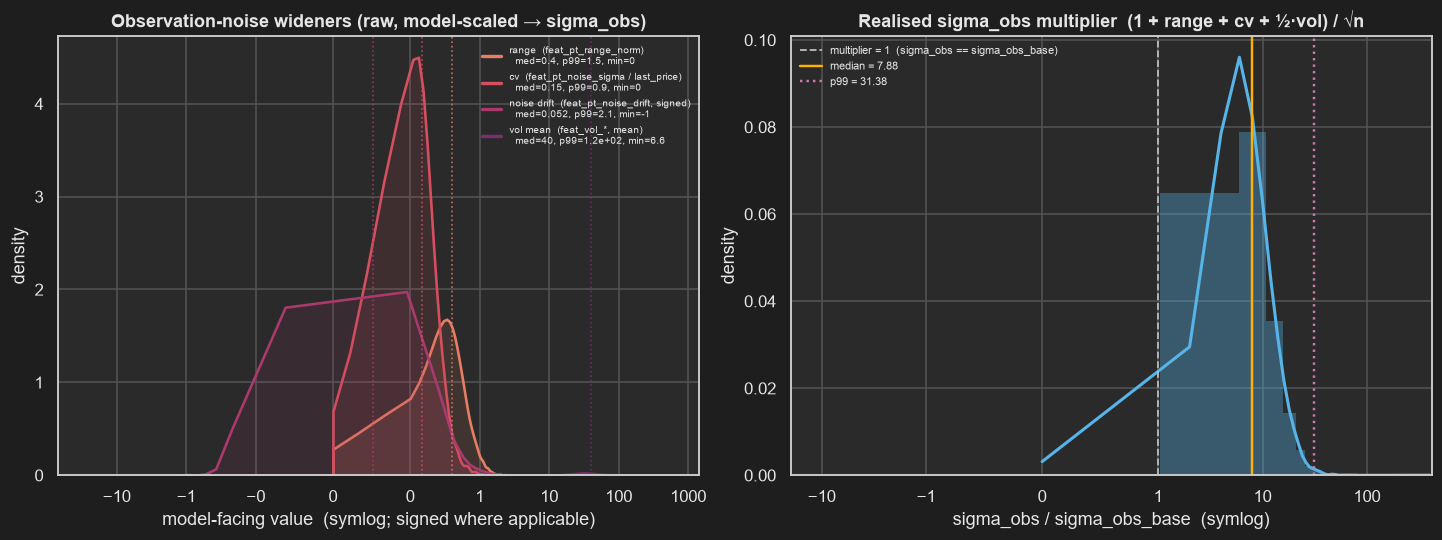

Observation-noise wideners (raw, un-winsorised, model-facing):
  - range  (feat_pt_range_norm)                median=      0.4  p99=      1.52  min=       0  (p99/median tail ratio=3.8)
  - cv  (feat_pt_noise_sigma / last_price)     median=     0.15  p99=     0.898  min=       0  (p99/median tail ratio=6.0)
  - noise drift  (feat_pt_noise_drift, signed) median=   0.0517  p99=      2.06  min=      -1  (p99/median tail ratio=39.9)
  - vol mean  (feat_vol_*, mean)               median=     39.8  p99=       123  min=    6.57  (p99/median tail ratio=3.1)
  sigma_obs multiplier: median=7.88, p99=31.38; 100% of names widen sigma_obs above base, 0% (high-coverage) tighten it below base.


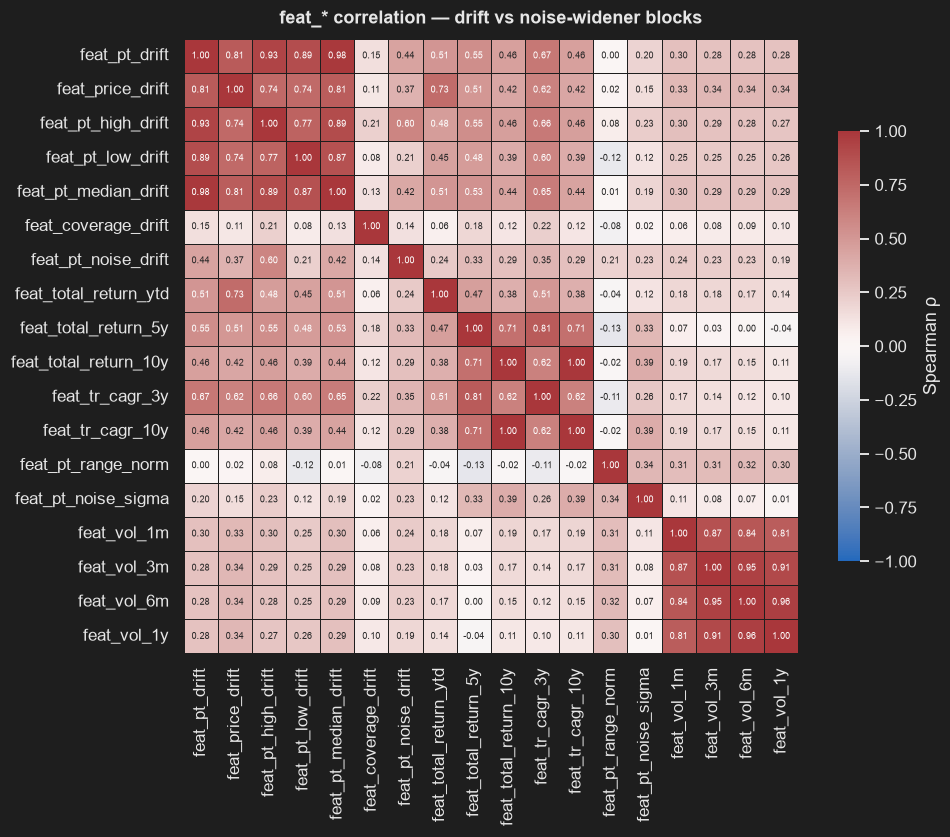

C:\Users\markm\PML_Finance_Project\pymc_kalman_filter_pt.py:894: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


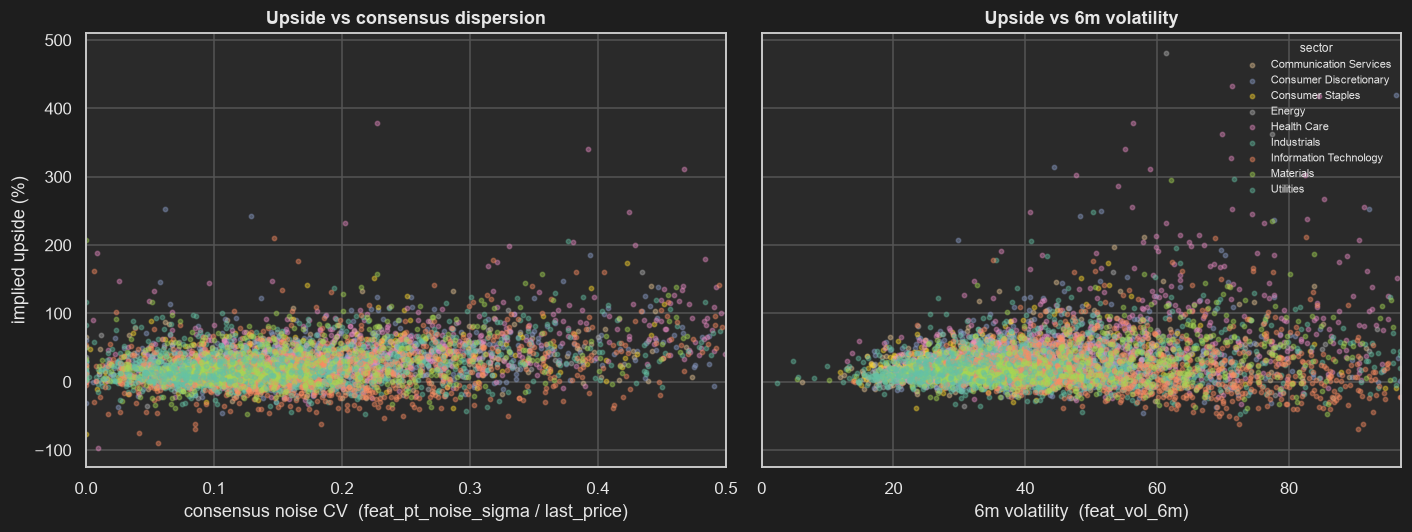

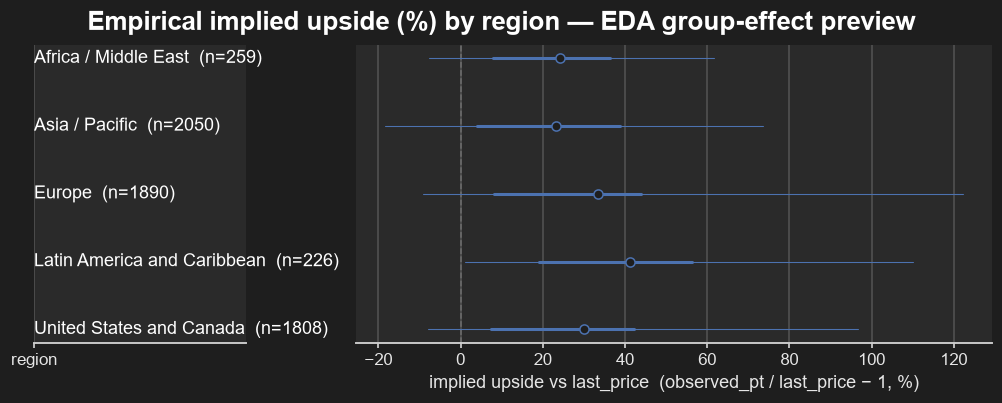

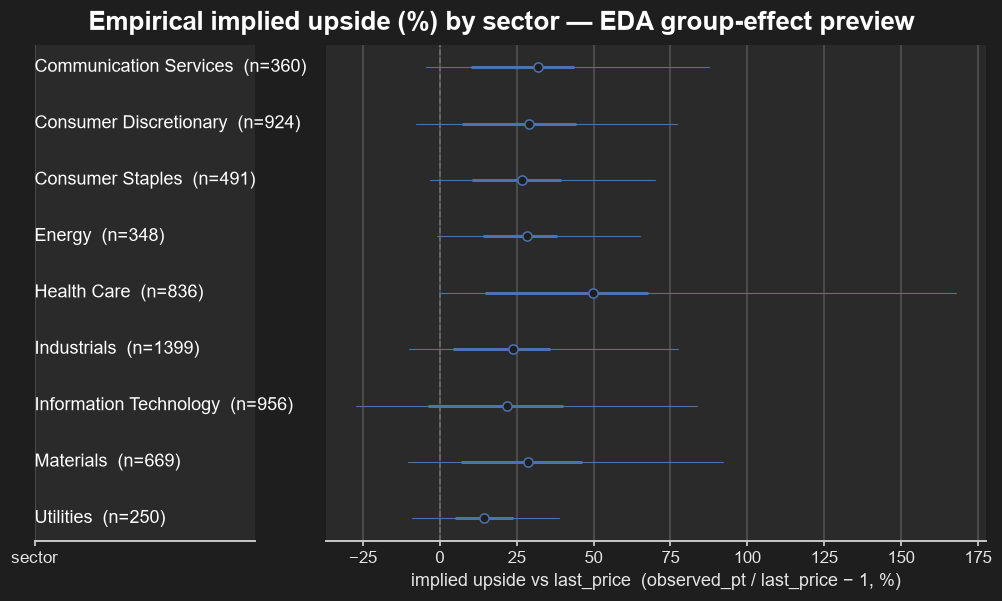

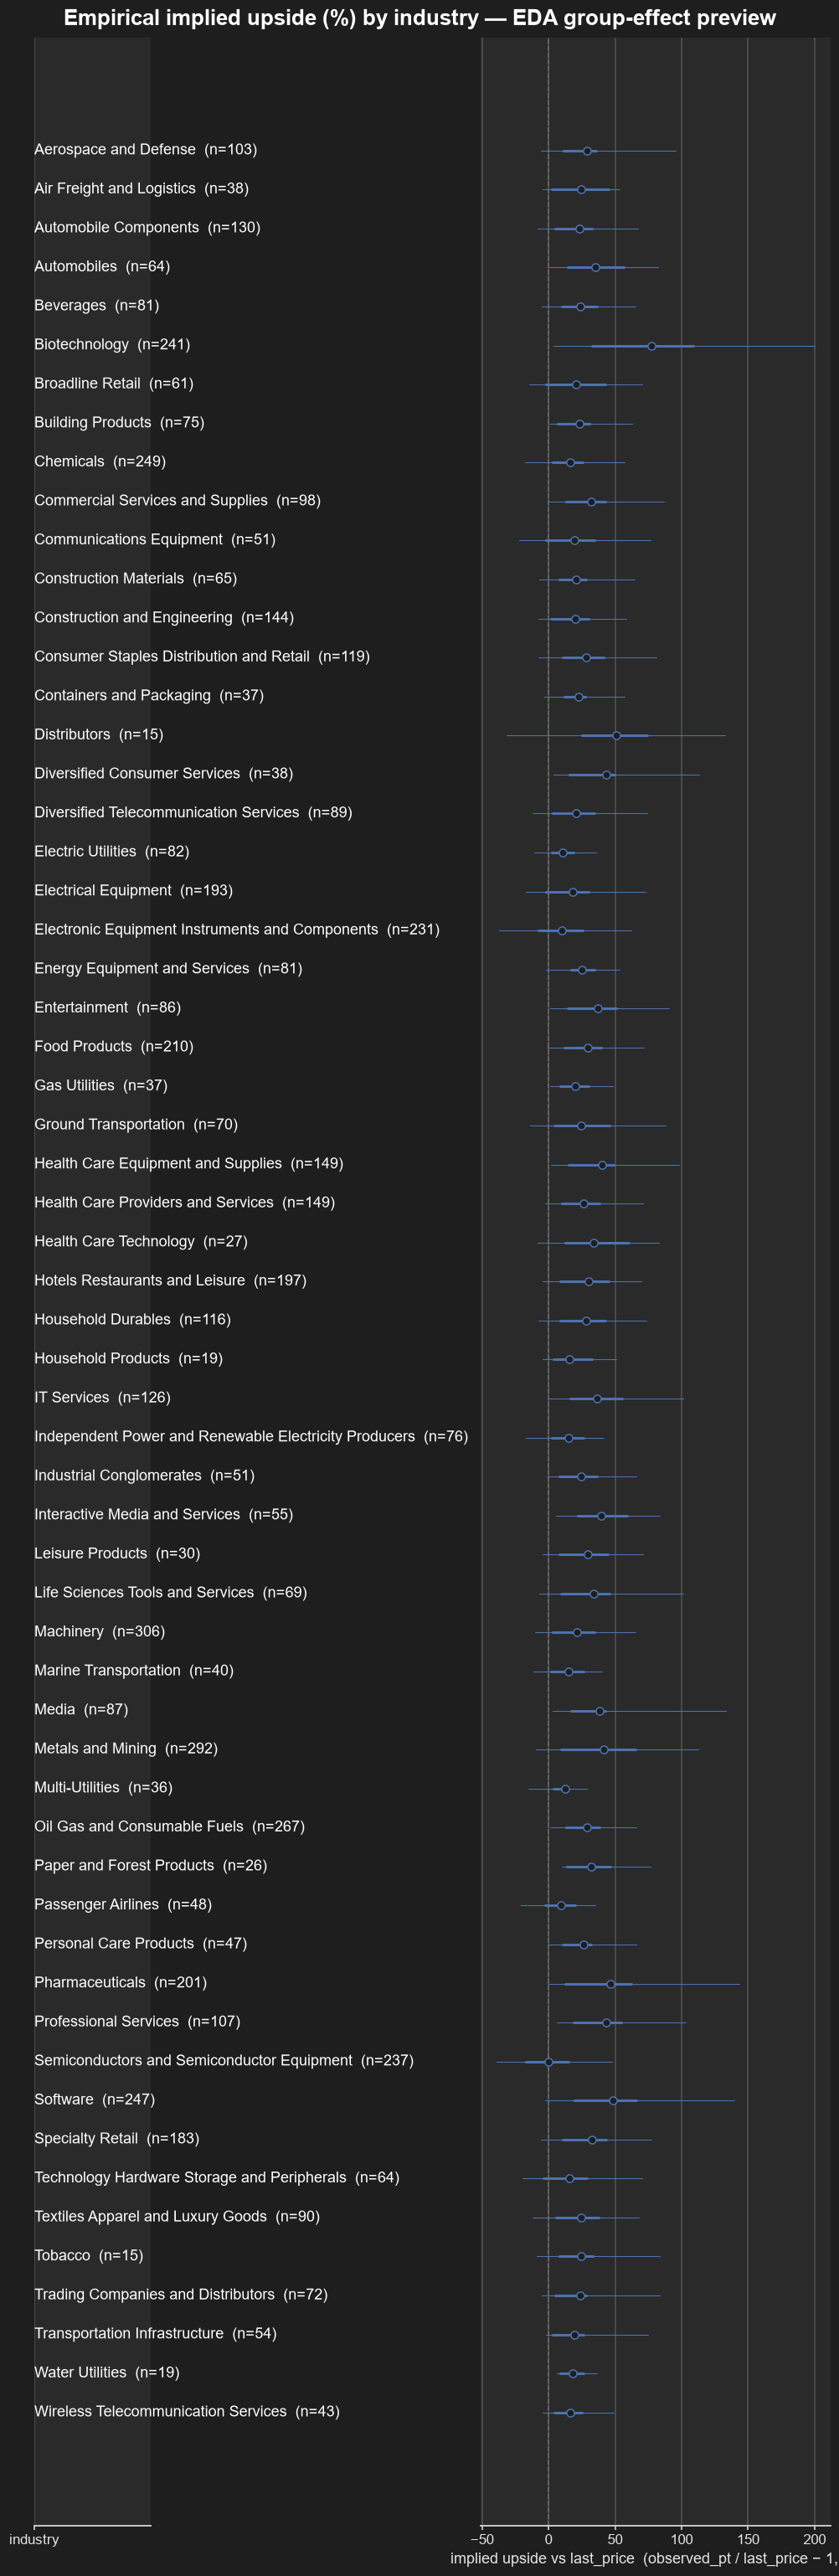

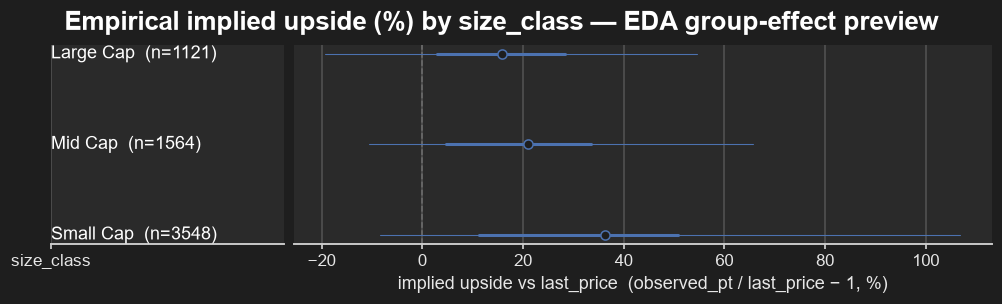

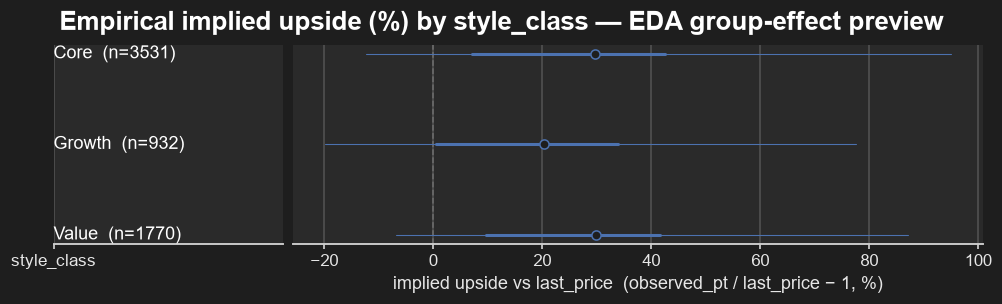

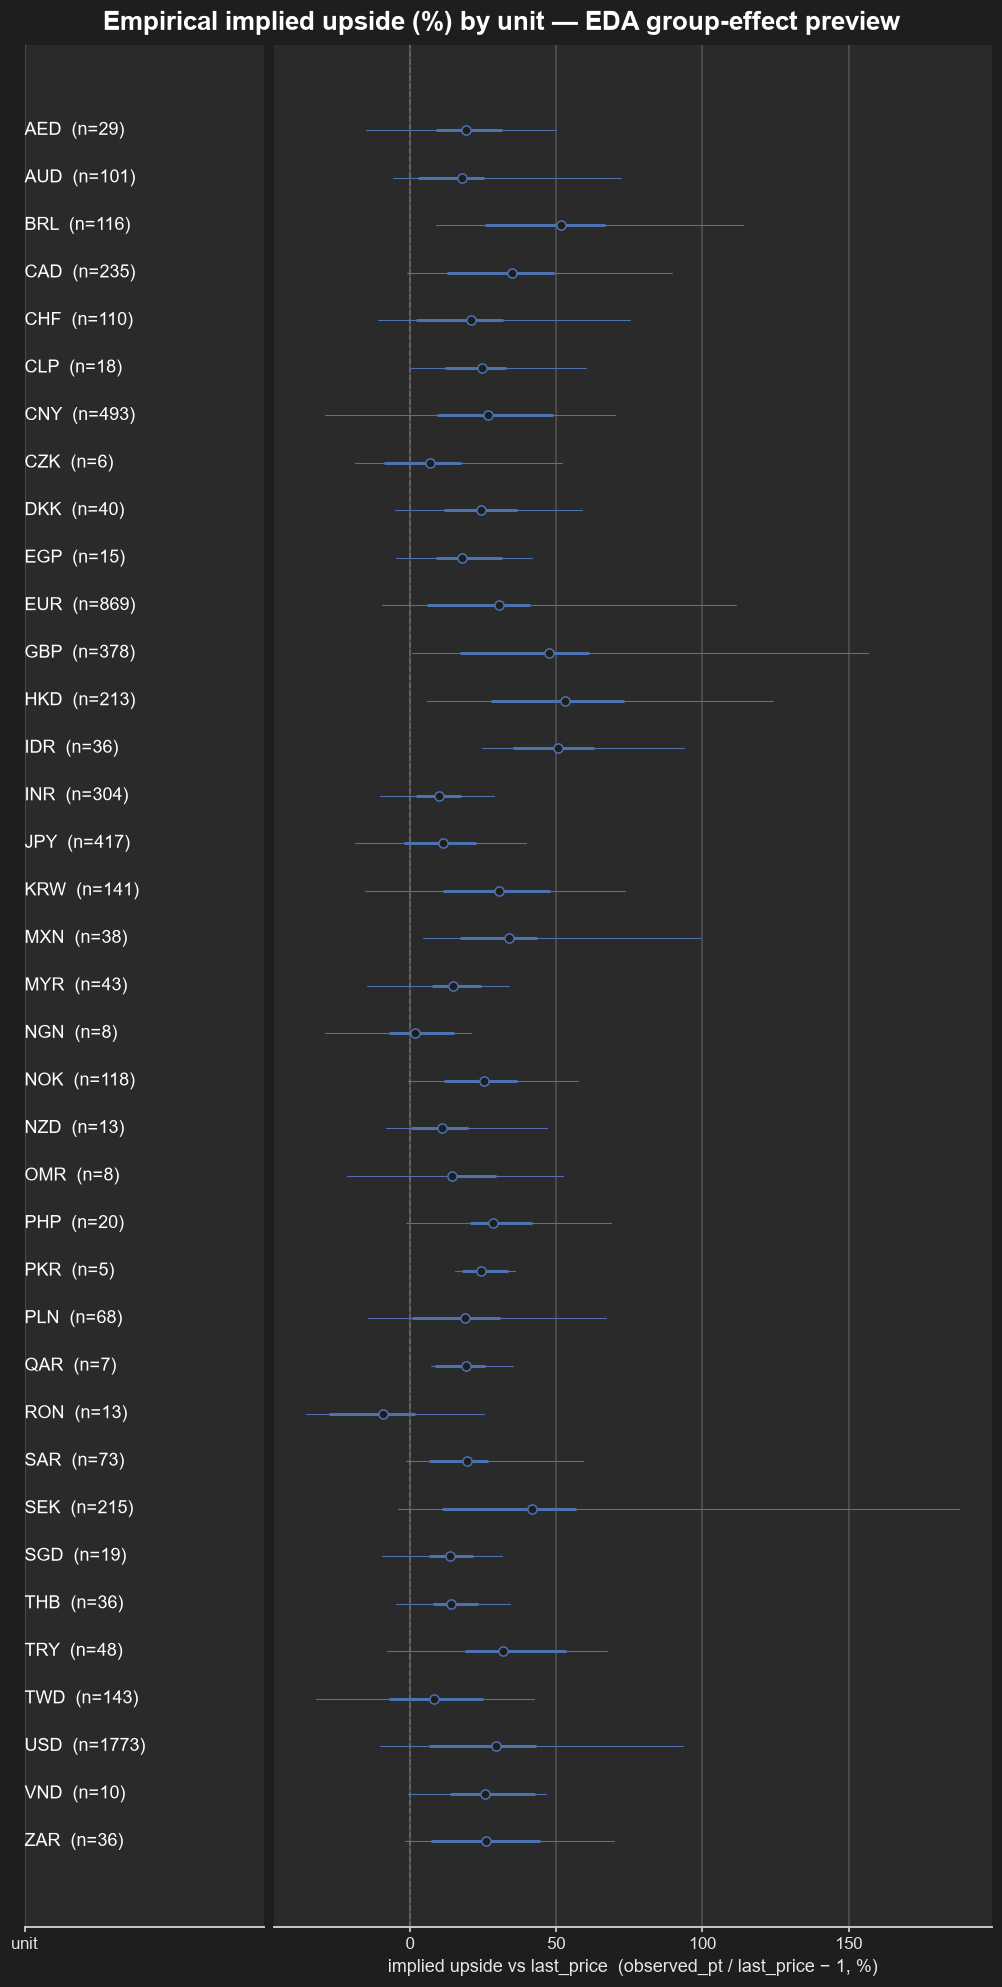

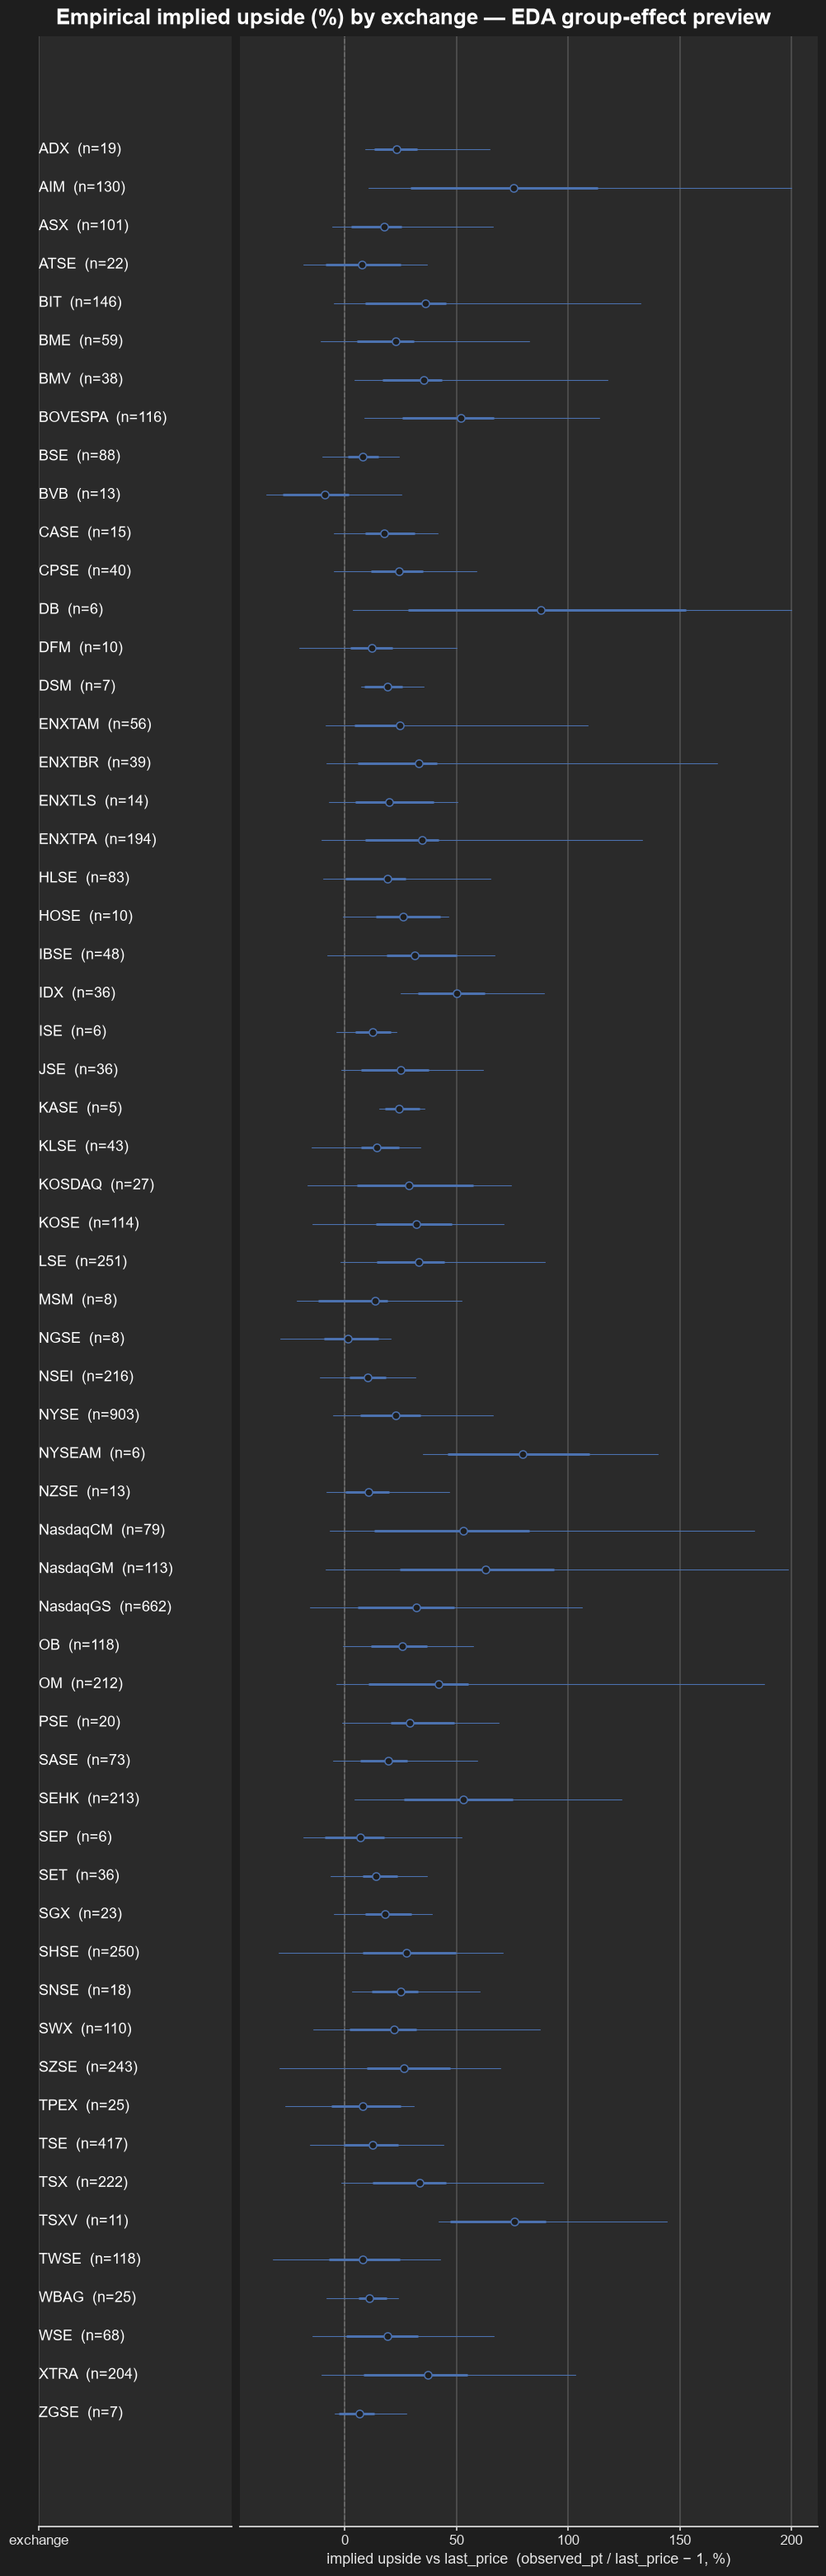

In [4]:
run_eda(kalman_df, roles)

## §3 — State-space feature mapping

`map_state_space_features` maps the `feat_*` columns onto Kalman roles and returns the
drift-feature list (state-transition mean / `beta` slopes). Alongside the analyst-trail
drifts and `feat_total_return_ytd`, the drift block now also carries the longer-horizon
realised-return features `feat_total_return_5y`, `feat_total_return_10y`, `feat_tr_cagr_3y`
and `feat_tr_cagr_10y` (sourced from the `total_return` / `tot_return_pct_cagr_*` columns,
registered as `kalman_pt` `mutable_predictor`s in `pml.vw_pymc_feature_catalogue`). They
add multi-horizon momentum signal; the long-horizon members are mutually collinear, so the
weakly-informative `beta` prior regularises their individual slopes.

> **Leakage guardrail:** `feat_implied_upside = (observed_pt − last_price)/last_price` is
> a deterministic function of the response, so it must never enter the drift-predictor
> matrix. The mapping asserts this.

In [5]:
drift_features, mapping = map_state_space_features(kalman_df)
mapping

Drift features : ['feat_pt_drift', 'feat_price_drift', 'feat_pt_high_drift', 'feat_pt_low_drift', 'feat_pt_median_drift', 'feat_coverage_drift', 'feat_total_return_ytd', 'feat_total_return_5y', 'feat_total_return_10y', 'feat_tr_cagr_3y', 'feat_tr_cagr_10y']
Noise drivers  : range=feat_pt_range_norm, sigma=feat_pt_noise_sigma, vol=['feat_vol_1m', 'feat_vol_3m', 'feat_vol_6m', 'feat_vol_1y']


,mv_column,state_space_role
0,feat_pt_drift,drift / state-transition mean (beta)
1,feat_price_drift,drift / state-transition mean (beta)
2,feat_pt_high_drift,drift / state-transition mean (beta)
3,feat_pt_low_drift,drift / state-transition mean (beta)
4,feat_pt_median_drift,drift / state-transition mean (beta)
5,feat_coverage_drift,drift / state-transition mean (beta)
6,feat_total_return_ytd,drift / state-transition mean (beta)
7,feat_total_return_5y,drift / state-transition mean (beta)
8,feat_total_return_10y,drift / state-transition mean (beta)
9,feat_tr_cagr_3y,drift / state-transition mean (beta)


,mv_column,state_space_role
0,feat_pt_drift,drift / state-transition mean (beta)
1,feat_price_drift,drift / state-transition mean (beta)
2,feat_pt_high_drift,drift / state-transition mean (beta)
3,feat_pt_low_drift,drift / state-transition mean (beta)
4,feat_pt_median_drift,drift / state-transition mean (beta)
5,feat_coverage_drift,drift / state-transition mean (beta)
6,feat_total_return_ytd,drift / state-transition mean (beta)
7,feat_total_return_5y,drift / state-transition mean (beta)
8,feat_total_return_10y,drift / state-transition mean (beta)
9,feat_tr_cagr_3y,drift / state-transition mean (beta)


## §4 — Fused-panel data containers

`prepare_kalman_panel_inputs` filters to log-space-usable rows and builds the
`KalmanPanelInputs`: the standardised `(isin, time, y_series)` response tensor `Y`, the
fiscal-anchor time matrix `t_scaled`, the standardised drift design matrix, the
volatility / dispersion-cv / √n noise drivers, and the categorical group-effect coords.

> **Primary response = log uplift.** The first (anchor) response series is
> `feat_log_uplift = log1p(feat_implied_upside)`, winsorised to implied upside
> ∈ [−95 %, +500 %] before the log. Modelling the **log** uplift keeps the
> reconstructed price target strictly positive
> (`expected_pt = last_price · exp(log_uplift)`): the raw decimal `feat_implied_upside`
> is unbounded below, so de-standardising the Gaussian baseline linearly
> (`last_price · (1 + eu)`) produced **negative** `expected_pt` for names trading far
> above their analyst targets (extreme YTD momentum run-ups). `observed_pt` is dropped
> as a response — it is a near-collinear price-level restatement of the primary series.


In [6]:
panel = prepare_kalman_panel_inputs(kalman_df, roles, drift_features)
print("Y shape (isin, time, y_series):", panel.Y.shape)
print("response_names:", panel.response_names)
print("drift_names   :", panel.drift_names)

Fused panel — isins:6233  T:1  D:2 (['feat_log_uplift', 'feat_pt_drift'])
  drift_features:11  avg_beta(mean):0.786  expected_vol(mean):45.537  cv(mean):0.196
Y shape (isin, time, y_series): (6233, 1, 2)
response_names: ['feat_log_uplift', 'feat_pt_drift']
drift_names   : ['feat_pt_drift', 'feat_price_drift', 'feat_pt_high_drift', 'feat_pt_low_drift', 'feat_pt_median_drift', 'feat_coverage_drift', 'feat_total_return_ytd', 'feat_total_return_5y', 'feat_total_return_10y', 'feat_tr_cagr_3y', 'feat_tr_cagr_10y']


## §5 — Build the fused MvGRW model

`build_panel_model` wraps `build_fused_kalman_pt_model` and renders the model graph.

### Generative form

Per ISIN $i$, fiscal-anchor time $t$, and response series $d$ (the primary anchor series
$d=0$ is `feat_log_uplift`). The fused model collapses two notebook models into one
builder: a systematic-risk-conditioned cross-sectional drift baseline (**Model A**) supplies
the per-ISIN level of a diagonal multivariate Gaussian random-walk spine (**Model B**).

**Model A — systematic-risk-conditioned drift baseline.** A hierarchical regression on the
standardised drift design $X^{\text{drift}}$ with crossed, sum-to-zero group intercepts
(`region` / `sector` / `size_class` / `style_class`) sharing a **single** scale
$\sigma_{\text{group}}$:

$$\eta_i = X^{\text{drift}}_i\,\beta + \sum_g \big(\sigma_{\text{group}}\,z^{(g)}\big)_{[i]}, \qquad \beta \sim \mathcal{N}(0, 1),\ \ z^{(g)} \sim \text{ZeroSumNormal}(1),\ \ \sigma_{\text{group}} \sim \text{HalfNormal}(0.5)$$
$$\text{expected\_return}_i = \eta_i \qquad\text{(deterministic structural mean — no per-ISIN signal latent)}$$
$$\text{risk\_adj\_return}_i = \text{expected\_return}_i \cdot \exp\!\big(-\lambda\, z(\text{avg\_beta})_i\big) \;=:\; \mu^{\text{isin}}_i$$

The risk penalty $\lambda$ (`risk_penalty`, default `0.1`) tilts the return by the
**standardised** (z-scored) average market **beta** — the CAPM systematic-risk
measure — a *relative* $\exp(\pm\lambda)$ cross-sectional discount with mean ≈ 1 that
demotes high-beta names and lifts low-beta ones. Beta isolates the priced,
non-diversifiable risk that should discount expected return, replacing the earlier
expected-volatility penalty (which conflated idiosyncratic noise and, fed as a raw
percent level ≈ 45, produced an $\exp(-4.5)\approx0.01$ discount that annihilated the
regression). Expected volatility (`feat_vol_*`) is retained as a provenance container
only. A non-centred logit-normal $\text{achieve\_prob}_i = \sigma(\mu_{\text{logit}} + \sigma_{\text{logit}}\,z_i)$
is carried alongside for downstream consumers.

**Model B — diagonal MvGRW spine.** A NUTS-safe multivariate random walk over
$(\text{time}, \text{y\_series})$ with non-centred level $\alpha$ and slope $\beta_t$
walks, combined with the per-ISIN baseline through per-series factor loadings $\ell_d$
(the primary series anchored at $\ell_0 \equiv 1$, others $\sim \mathcal{N}(1, 0.5)$):

$$\alpha_{t,d} = \sum_{s \le t} \sigma^{\alpha}_d\, z^{\alpha}_{s,d}, \qquad \beta_{t,d} = \sum_{s \le t} \sigma^{\beta}_d\, z^{\beta}_{s,d}, \qquad \sigma^{\alpha}_d,\sigma^{\beta}_d \sim \text{HalfNormal}(0.5)$$
$$\text{reg}_{i,t,d} = \alpha_{t,d} + \beta_{t,d}\,t^{\text{scaled}}_{i,t} + \ell_d\,\mu^{\text{isin}}_i$$

When $T > 1$ (a genuine time panel) both walks are anchored at $t=0$ — subtracting the
initial state — so $\mu^{\text{isin}}$ carries the level and the walk carries pure time
deviations. When the panel is collapsed to a single cross-sectional slice ($T = 1$, the
default one-row-per-ISIN `mv_pymc_kalman_pt` snapshot) the walk is **not** anchored:
$\alpha_{0,d}$ serves as the free per-series intercept and the model reduces to a
well-conditioned cross-sectional MvNormal/Student-t.

**Heteroscedastic robust likelihood.**

$$\sigma^{\text{isin}}_i = \sigma_{\text{base}}\,\frac{1 + \text{cv}_i}{w_i}, \qquad \sigma_{\text{base}} \sim \text{Exponential}(1),\ \ w_i = \sqrt{n^{\text{analysts}}_i / \operatorname{median}(n)}$$
$$Y_{i,t,d} \sim \text{StudentT}\!\big(\nu,\ \text{reg}_{i,t,d},\ \sigma^{\text{isin}}_i\big), \qquad \nu = 2.5 + \text{Gamma}(2, 0.1)$$

The consensus-noise coefficient of variation $\text{cv}_i$ widens noisy names; the
**median-normalised** analyst-precision weight $w_i$ tightens high-coverage names while
keeping the median name at $w_i \approx 1$ (raw $\sqrt{n}$ drove $\sigma^{\text{isin}}$
~10× too small on the z-scored response, collapsing the screen to full pooling). The hard
floor $\nu \ge 2.5$ guarantees finite variance and removes the improper
$\sigma_{\text{base}}\to0,\ \nu\to0$ corner. The posterior `expected_pt` de-standardises
the primary log-uplift series back through `last_price · exp(log_uplift)` — strictly
positive by construction. Pass `robust=False` for the Normal-likelihood twin (default is
the Student-t panel likelihood, which absorbs analyst outliers).

### NUTS-inplace-safety constraints baked into the builder

- `√n_analysts` is precomputed in NumPy and passed as `pm.Data` (never `pt.sqrt` on an
  integer container).
- `sigma_base` uses `pm.Exponential` (not `HalfNormal`) so no `Abs→Sqrt` rewrite fuses
  into an inplace `Composite` op.
- The GRW uses an explicit **diagonal** innovation parameterisation instead of
  `LKJCholeskyCov` (whose onion-method Beta→Normal chain triggers an inplace rewrite
  NUTS rejects).

### Sampler-geometry parameterisation

- `mu_global` is **dropped** — `mu_isin` is the model's sole identified level, removing
  the flat `mu_global` ↔ walk-level ridge that drove the ~0.001 step-size /
  max-tree-depth regime.
- Crossed group intercepts use a **non-centred `ZeroSumNormal` with one shared
  `sigma_group`**: the sum-to-zero constraint removes the additive level ridge and the
  single shared scale collapses the previously-unidentified 6-way variance partition
  (R-hat ≈ 3–4.4, ESS ≈ 4) into a clean between-group vs residual decomposition.
  `industry` is excluded (near-nested under `sector`); per-coord `sigma_<col>` are
  re-exposed as Deterministic aliases of `sigma_group`.
- `expected_return` is the **deterministic** structural mean `mu_reg`; the old per-ISIN
  signal latent (with its own `sigma_expected_return`) is removed and idiosyncratic
  per-ISIN dispersion is carried by the Student-t `sigma_isin` instead.

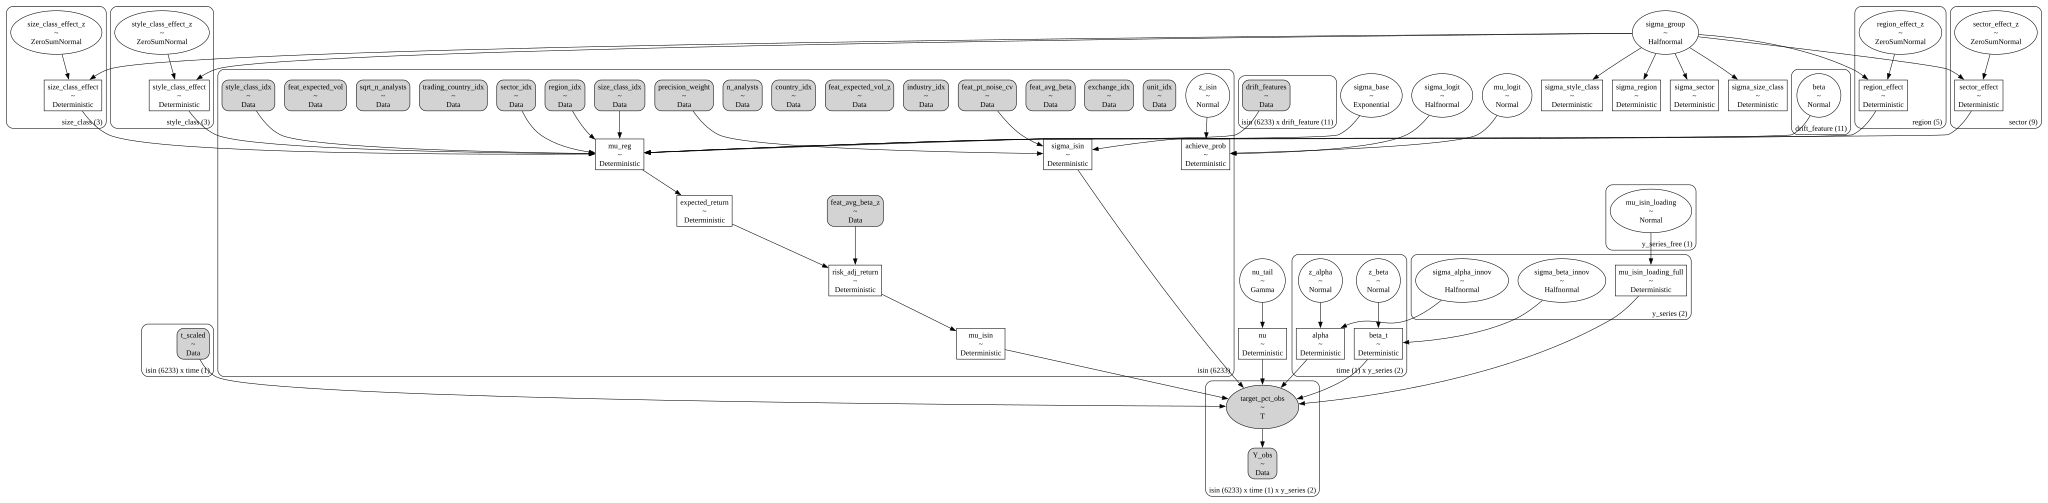

In [7]:
robust = True
model = build_panel_model(panel, robust=robust)
pm.model_to_graphviz(model)

## §6 — Prior predictive checks

`run_prior_predictive` draws 1000 prior samples of `expected_return`, `risk_adj_return`,
`achieve_prob` and `sigma_isin`, then renders three panels so the §5 refinements are
visible **before any data is seen**:

1. **Prior implied upside vs empirical** — the fused baseline `risk_adj_return` is
   de-standardised onto the primary `feat_implied_upside` series (via
   `panel_posterior_upside`) and overlaid on the empirical `observed_pt / last_price − 1`.
   A sane prior should bracket the empirical upside without concentrating mass at
   implausible returns.
2. **`achieve_prob` (logit-normal)** — the Model-A achievement probability
   $\sigma(\mu_{\text{logit}} + \sigma_{\text{logit}}\,z_i)$, which should span $(0,1)$
   without piling up at the bounds.
3. **`sigma_isin` (heteroscedastic scale)** — the measurement scale
   $\sigma_{\text{base}}(1+\text{cv})/w_i$, a positive right-skewed prior.

The predictive draw forces the pure-Python linker via `compile_kwargs`
(`get_pytensor_compile_kwargs()`), so it cannot stall on C compilation.

Sampling: [beta, mu_logit, region_effect_z, sector_effect_z, sigma_base, sigma_group, sigma_logit, size_class_effect_z, style_class_effect_z, z_isin]
INFO:pymc.sampling.forward:Sampling: [beta, mu_logit, region_effect_z, sector_effect_z, sigma_base, sigma_group, sigma_logit, size_class_effect_z, style_class_effect_z, z_isin]
C:\Users\markm\PML_Finance_Project\pymc_kalman_filter_pt.py:1589: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


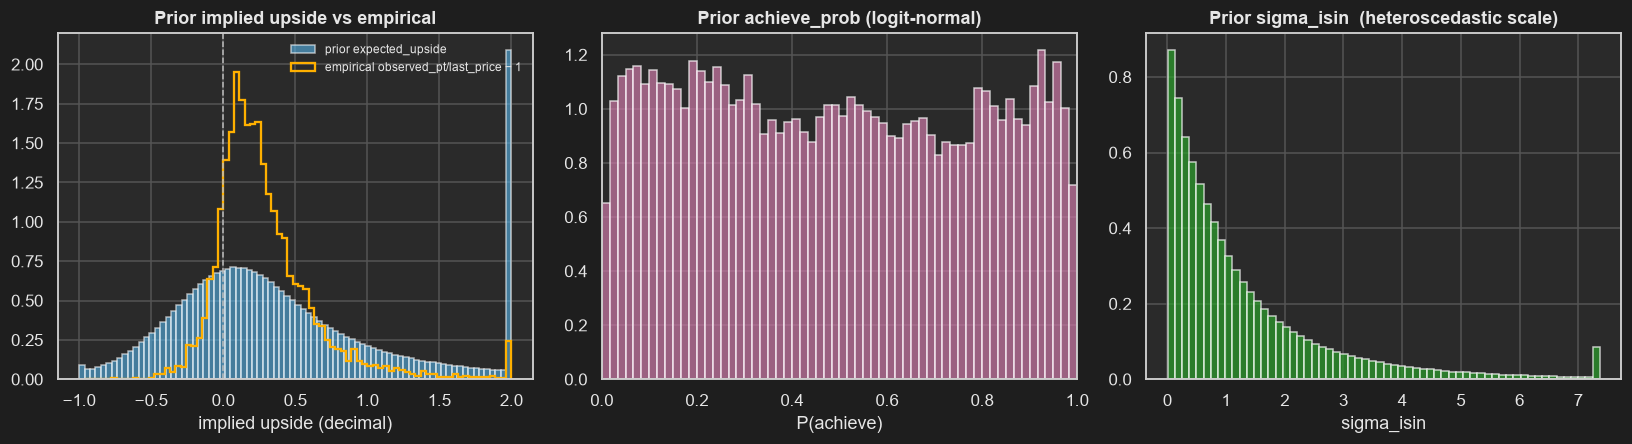

Prior expected_upside: median=0.247, p01/p99=(-0.87, 10.98); empirical median=0.214.


In [8]:
prior_idata = run_prior_predictive(model, panel)

## §7 — Posterior inference (NUTS)

`sample_posterior` tries `nutpie → numpyro → pymc` in priority order (whichever is
installed; pure-Python `pymc` NUTS is always the fallback) and merges the prior groups
into the posterior `DataTree` for one-object downstream access.

**Sampler settings** (see `sample_posterior`): `draws=1500, tune=2000, chains=4,
cores=4, target_accept=0.97`. 4×1500 = 6000 draws and `cores=4` runs all chains in
parallel.

> **The decisive fix is structural, not budgetary.** Once §4 collapsed the inert tiled
> time axis to a single cross-sectional slice (`T=1`) and `build_fused_kalman_pt_model`
> dropped the per-ISIN signal latent (`sigma_expected_return` + `z_expected_return`) and
> collapsed the five crossed group scales into one shared `sigma_group` (with `industry`
> removed), the variance structure became **identified**. Previously those six variance
> components formed an unidentified partition over the same per-ISIN dispersion — every
> scale stuck at R-hat ≈ 4.4, ESS ≈ 4 — which no sampling budget could fix. With the
> model well-conditioned, `tune=2000` / `target_accept=0.97` are kept purely as
> insurance to push the minimum ESS comfortably over 400.

> This is the long-running cell. With the `cxx` path fixed (§0), nutpie compiles via
> numba — no g++ stall.

In [9]:
idata = sample_posterior(model, prior_idata)
print("Group effects fitted:", present_group_effects(idata))
idata.posterior

Available NUTS samplers (in priority order): ['nutpie', 'numpyro', 'pymc']


NUTS[nutpie]: [mu_logit, sigma_logit, z_isin, beta, sigma_group, region_effect_z, sector_effect_z, size_class_effect_z, style_class_effect_z, sigma_alpha_innov, sigma_beta_innov, z_alpha, z_beta, mu_isin_loading, sigma_base, nu_tail]
INFO:pymc.sampling.mcmc:NUTS[nutpie]: [mu_logit, sigma_logit, z_isin, beta, sigma_group, region_effect_z, sector_effect_z, size_class_effect_z, style_class_effect_z, sigma_alpha_innov, sigma_beta_innov, z_alpha, z_beta, mu_isin_loading, sigma_base, nu_tail]
INFO:C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\pytensor\link\c\lazylinker_c.py:Compiling new CVM


Output()

Sampled successfully with nuts_sampler='nutpie'.
Group effects fitted: ['region', 'sector', 'size_class', 'style_class']


<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:               (chain: 4, draw: 1500, isin: 6233, drift_feature: 11,
                               time: 1, y_series: 2, y_series_free: 1, region: 5,
                               sector: 9, size_class: 3, style_class: 3)
    Coordinates:
      * chain                 (chain) int64 32B 0 1 2 3
      * draw                  (draw) int64 12kB 0 1 2 3 4 ... 1496 1497 1498 1499
      * isin                  (isin) object 50kB 'US67066G1040' ... 'BRLJQQACNOR5'
      * drift_feature         (drift_feature) object 88B 'feat_pt_drift' ... 'fea...
      * time                  (time) int64 8B 0
      * y_series              (y_series) object 16B 'feat_log_uplift' 'feat_pt_dr...
      * y_series_free         (y_series_free) object 8B 'feat_pt_drift'
      * region                (region) object 40B 'Africa / Middle East' ... 'Uni...
      * sector                (sector) object 72B 'Communication Services' ... 'U...
      * size_class            (size_class) object 24B 'Large Cap' ... 'Small Cap'
      * style_class           (style_class) object 24B 'Core' 'Growth' 'Value'
    Data variables: (12/34)
        mu_logit              (chain, draw) float64 48kB 0.09988 1.321 ... 1.086
        z_isin                (chain, draw, isin) float64 299MB -1.621 ... -1.418
        beta                  (chain, draw, drift_feature) float64 528kB 0.2109 ....
        z_alpha               (chain, draw, time, y_series) float64 96kB -0.5024 ...
        z_beta                (chain, draw, time, y_series) float64 96kB 0.5406 ....
        mu_isin_loading       (chain, draw, y_series_free) float64 48kB -0.001443...
        ...                    ...
        mu_isin               (chain, draw, isin) float64 299MB 1.453 ... 1.458
        alpha                 (chain, draw, time, y_series) float64 96kB -0.2314 ...
        beta_t                (chain, draw, time, y_series) float64 96kB 0.07395 ...
        mu_isin_loading_full  (chain, draw, y_series) float64 96kB 1.0 ... 0.0003246
        sigma_isin            (chain, draw, isin) float64 299MB 0.05987 ... 0.2992
        nu                    (chain, draw) float64 48kB 2.501 2.501 ... 2.502 2.502
    Attributes:
        created_at:                 2026-06-21T20:20:28.616979+00:00
        creation_library:           ArviZ
        creation_library_version:   1.2.0
        creation_library_language:  Python
        sample_dims:                ['chain', 'draw']
        inference_library:          nutpie
        inference_library_version:  0.16.10
        sampling_time:              282.0688998699188
        tuning_steps:               2000

## §8 — Posterior predictive checks

The fused likelihood `target_pct_obs` is the standardised `(isin, time, y_series)`
response tensor, so `run_posterior_predictive` pools the replicated draws against the
observed standardised responses and reports calibration four ways:

- **(a) ArviZ `plot_ppc_dist`** (ECDF kind) — replicated vs observed distribution.
- **(b) Pooled ECDF overlay** — ~60 posterior-predictive draws (light) against the
  observed ECDF (bold), a robust fallback for the multidimensional response.
- **(c) Per-`y_series` 94 % coverage** — the fraction of observed values inside the
  per-series $[\,3\%,\,97\%\,]$ posterior-predictive quantile band, which should land
  near **0.94**. Material under-coverage flags an over-confident `sigma_isin`;
  over-coverage flags an inflated one.
- **(d) ArviZ `plot_ppc_pit`** — the PIT calibration plot should track the diagonal
  (best-effort; skipped cleanly if the multidim PIT is unavailable).

Sampling: [target_pct_obs]
INFO:pymc.sampling.forward:Sampling: [target_pct_obs]


Output()

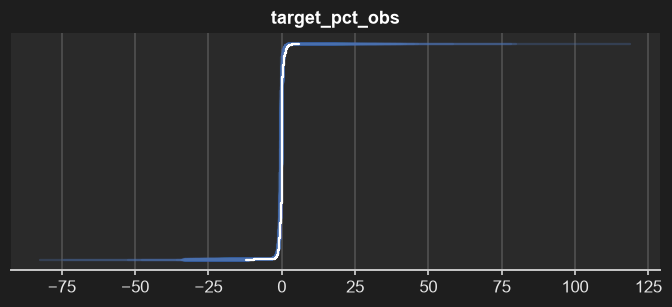

C:\Users\markm\PML_Finance_Project\pymc_kalman_filter_pt.py:1709: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


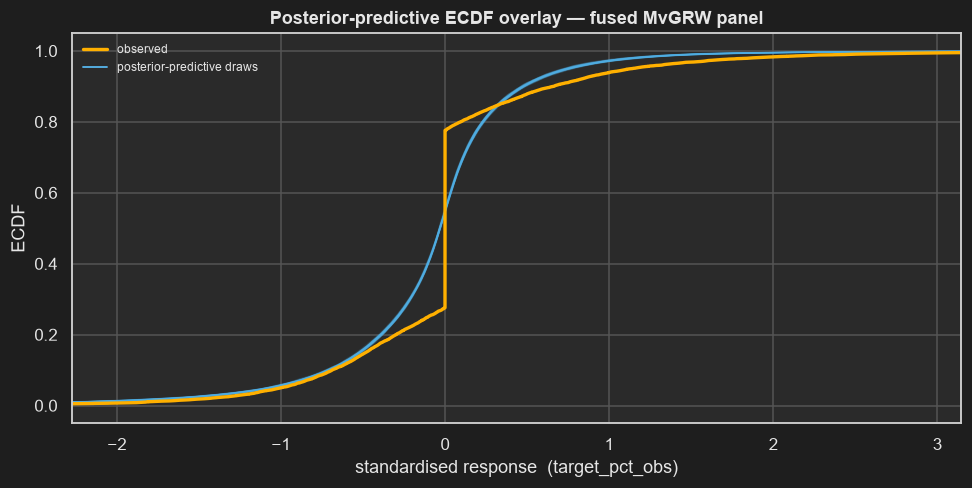

Per-y_series 94% posterior-predictive coverage (target ≈ 0.94):
  - feat_log_uplift         : 66.42%
  - feat_pt_drift           : 100.00%
PPC PIT calibration plot skipped: TypeError('only 0-dimensional arrays can be converted to Python scalars')


In [10]:
run_posterior_predictive(model, idata, panel)

## §9 — MCMC diagnostics

`run_diagnostics` reports R-hat / bulk-&-tail-ESS summaries, the divergence count, and
trace / rank-dist / forest views over the fused-model hyper-parameters: the global
scalars (`FUSED_SCALAR_VARS`), the per-coord hierarchical scales `sigma_<coord>`, the
drift slopes `beta`, and the GRW innovation scales `sigma_alpha_innov` /
`sigma_beta_innov`. Empty-dim variables (absent group effects) are skipped and reported.

The convergence gates follow Vehtari et al. (2021): **R-hat < 1.01** and **ESS > 400**.
After the §5 identifiability fixes the previously-stuck variance scales
(`sigma_<coord>`, the dropped `sigma_expected_return`) should now clear both gates and
the divergence count should be ≈ 0 — the diagnostics here confirm that the shared
`sigma_group` / deterministic-`expected_return` reparameterisation actually took.

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_alpha_innov[feat_log_uplift],0.3977,0.2460,0.1276,0.8697,70.5970,105.6765,1.0472,0.0235,0.0248
sigma_alpha_innov[feat_pt_drift],0.1056,0.1852,0.0008,0.4826,78.3845,127.0258,1.0448,0.0081,0.0143
sigma_sector,0.0983,0.0186,0.0725,0.1313,289.4864,501.6712,1.0326,0.0011,0.0009
sigma_region,0.0983,0.0186,0.0725,0.1313,289.4864,501.6712,1.0326,0.0011,0.0009
sigma_group,0.0983,0.0186,0.0725,0.1313,289.4864,501.6712,1.0326,0.0011,0.0009
sigma_style_class,0.0983,0.0186,0.0725,0.1313,289.4864,501.6712,1.0326,0.0011,0.0009
sigma_size_class,0.0983,0.0186,0.0725,0.1313,289.4864,501.6712,1.0326,0.0011,0.0009
sigma_beta_innov[feat_log_uplift],0.2574,0.2260,0.0456,0.7215,135.3032,134.8251,1.0125,0.0144,0.0161
sigma_beta_innov[feat_pt_drift],0.1068,0.1785,0.0008,0.4693,282.8166,352.1789,1.0113,0.0056,0.0094
beta[feat_pt_drift],0.0636,0.0844,-0.0689,0.1993,342.8638,607.7110,1.0058,0.0046,0.0032


C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\arviz_stats\base\diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


Divergences: 1  <-- non-zero: inspect the funnel partners below
Max R-hat:   1.0952  (gate < 1.01)
Min ESS:     30.7  (gate > 400)
Group-effect scale diagnostics  (R-hat, ESS-bulk, ESS-tail, status):
  -         sigma_region: r_hat= 1.033  ess_bulk=  289.5  ess_tail=  501.7  [WARN]
  -         sigma_sector: r_hat= 1.033  ess_bulk=  289.5  ess_tail=  501.7  [WARN]
  -     sigma_size_class: r_hat= 1.033  ess_bulk=  289.5  ess_tail=  501.7  [WARN]
  -    sigma_style_class: r_hat= 1.033  ess_bulk=  289.5  ess_tail=  501.7  [WARN]
Variance partition (posterior-mean scales, share of total):
  -                        sigma_group:  0.0983  (  43%)
  -                         sigma_base:  0.1313  (  57%)


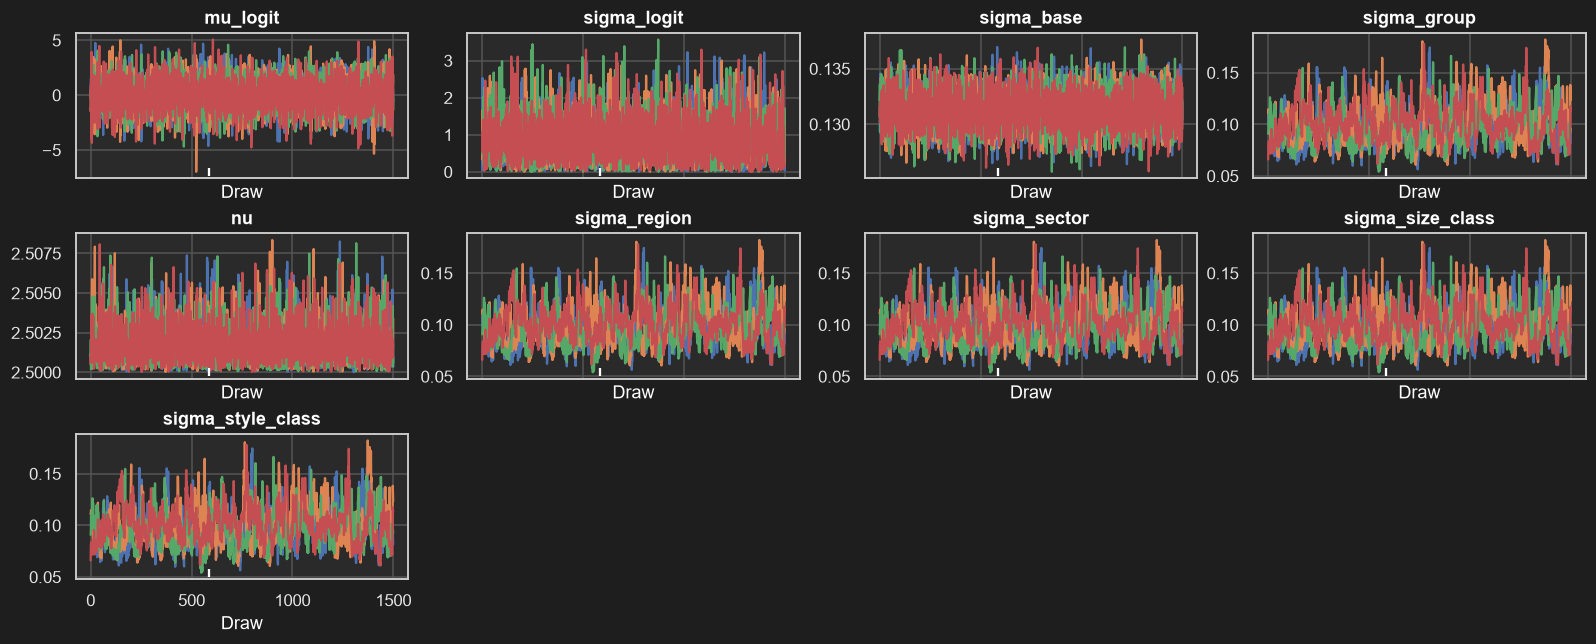

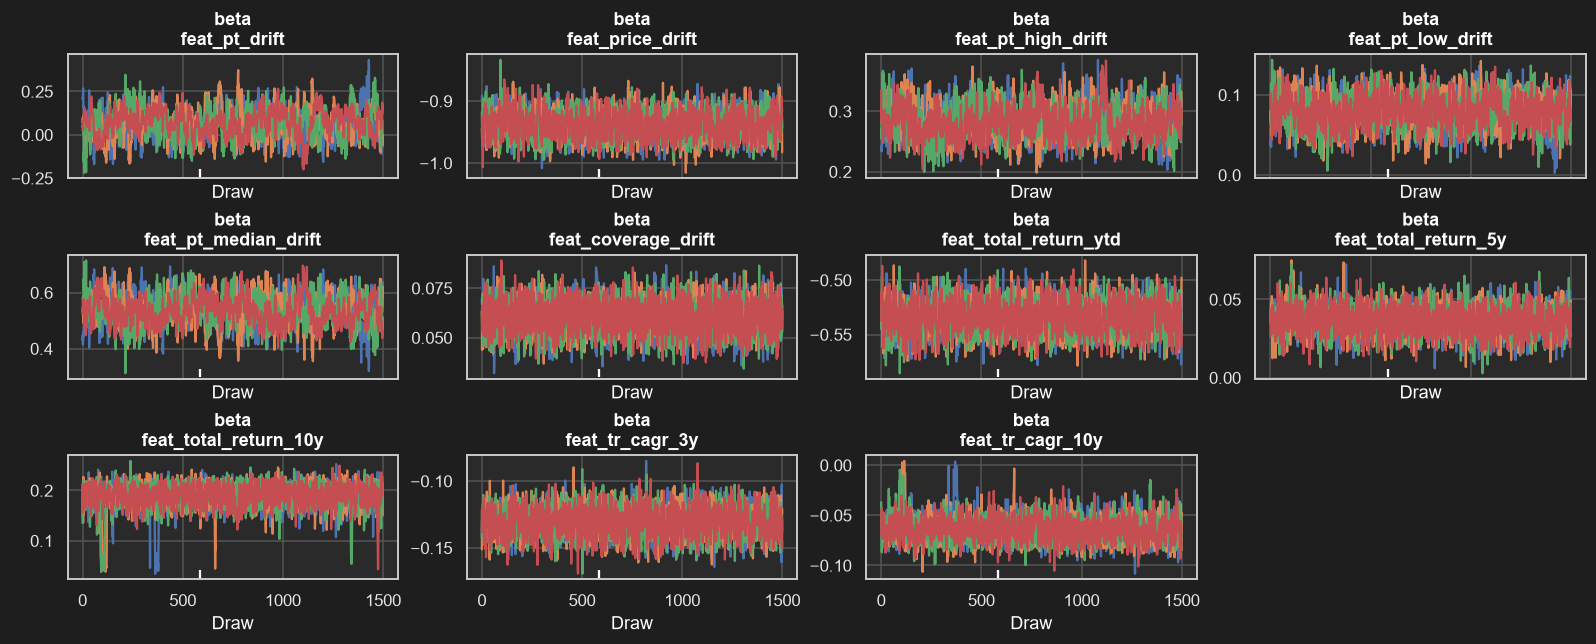

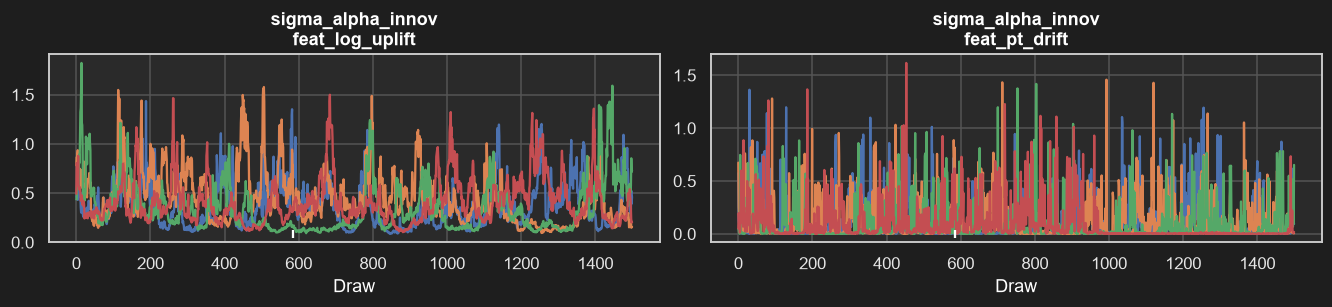

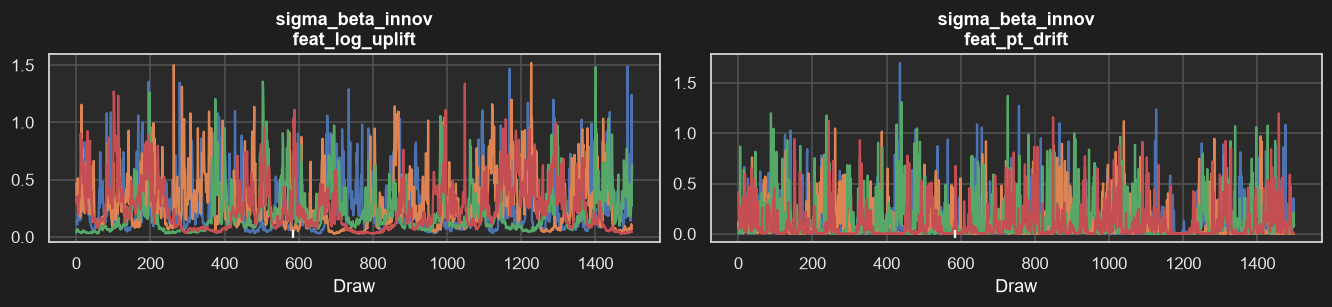

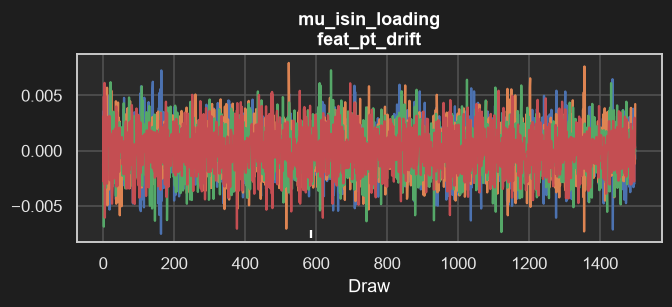

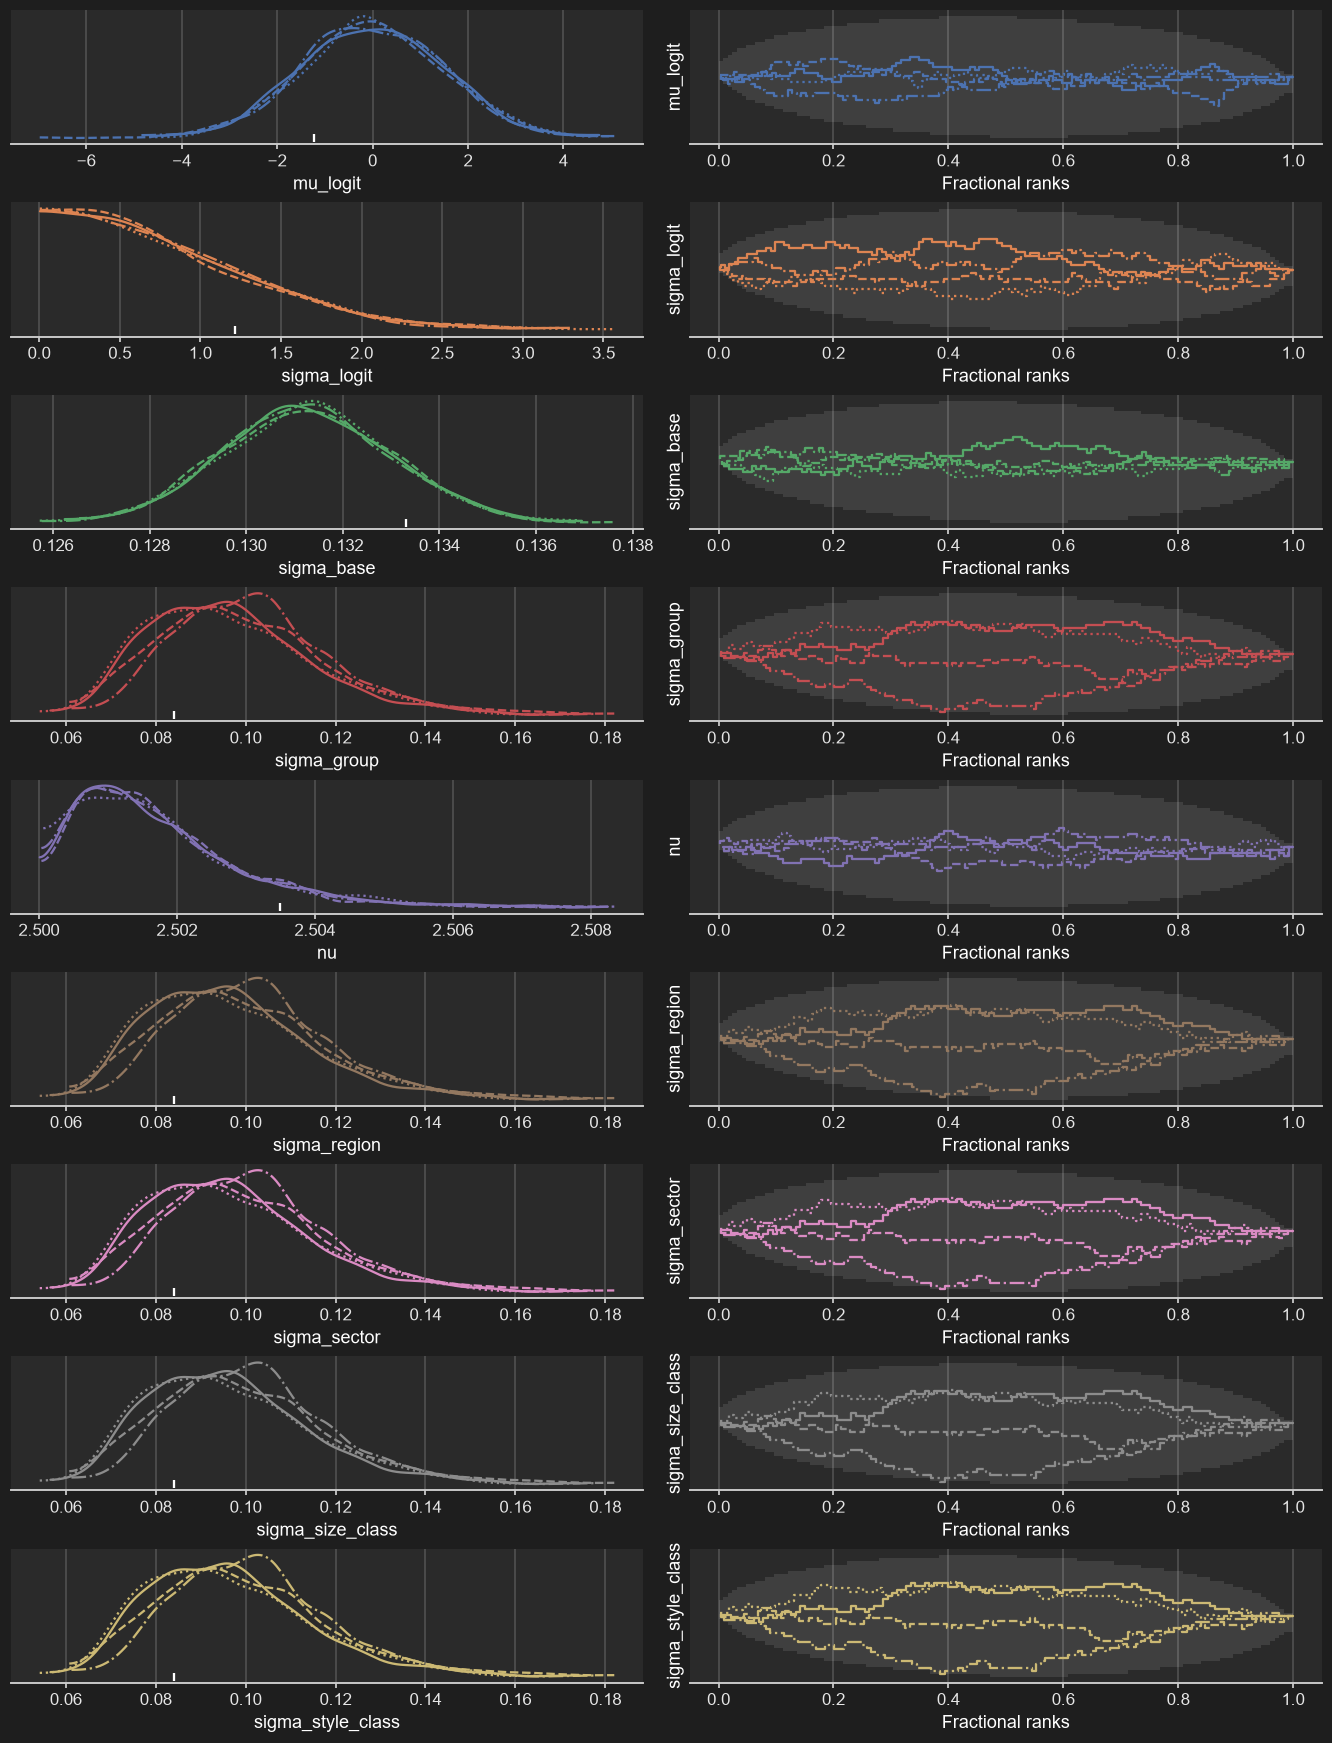

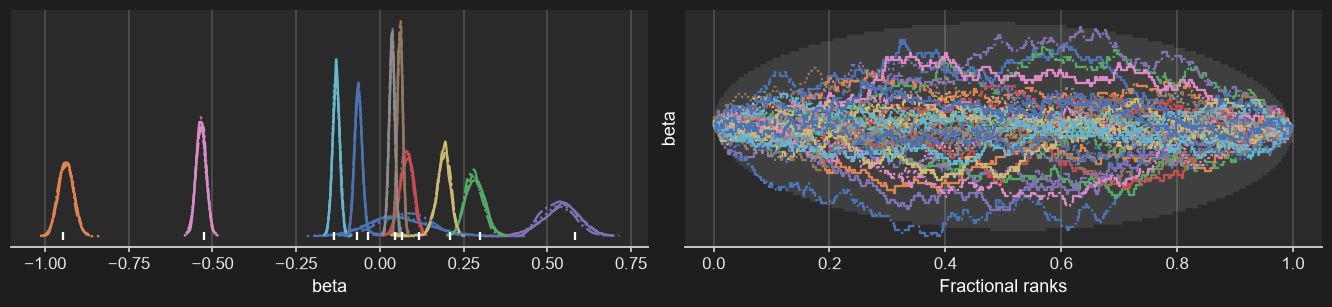

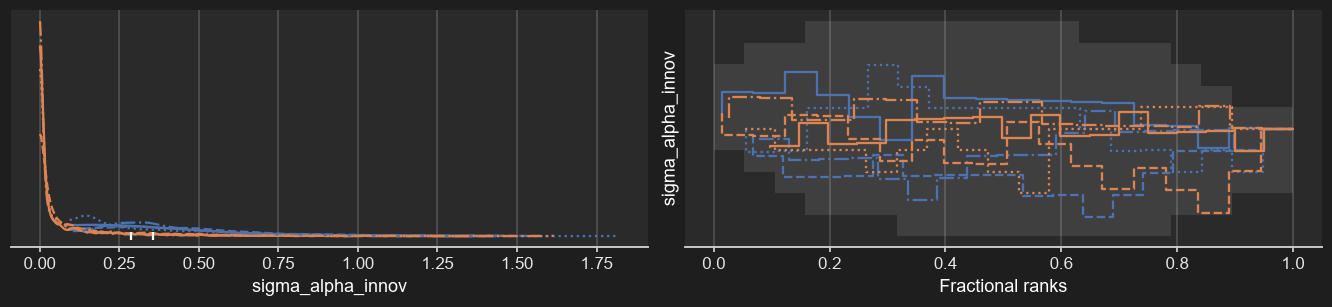

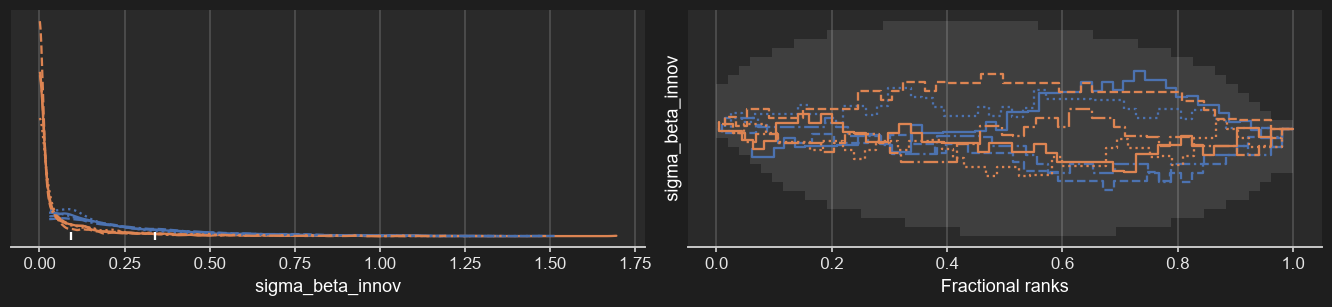

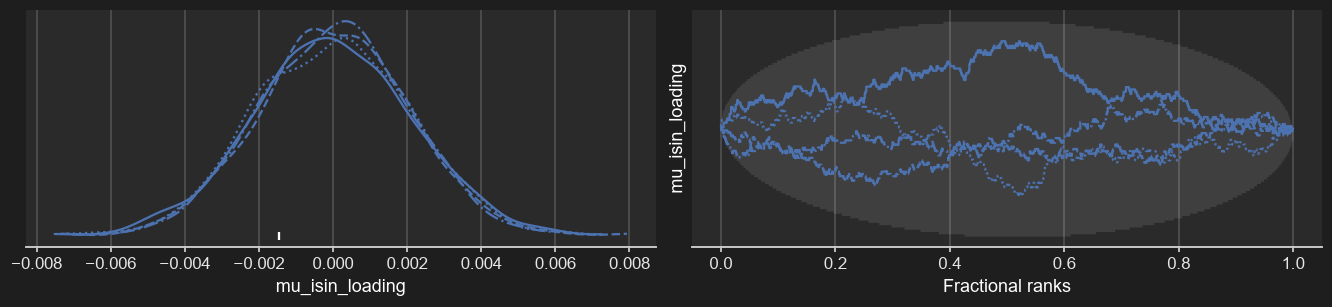

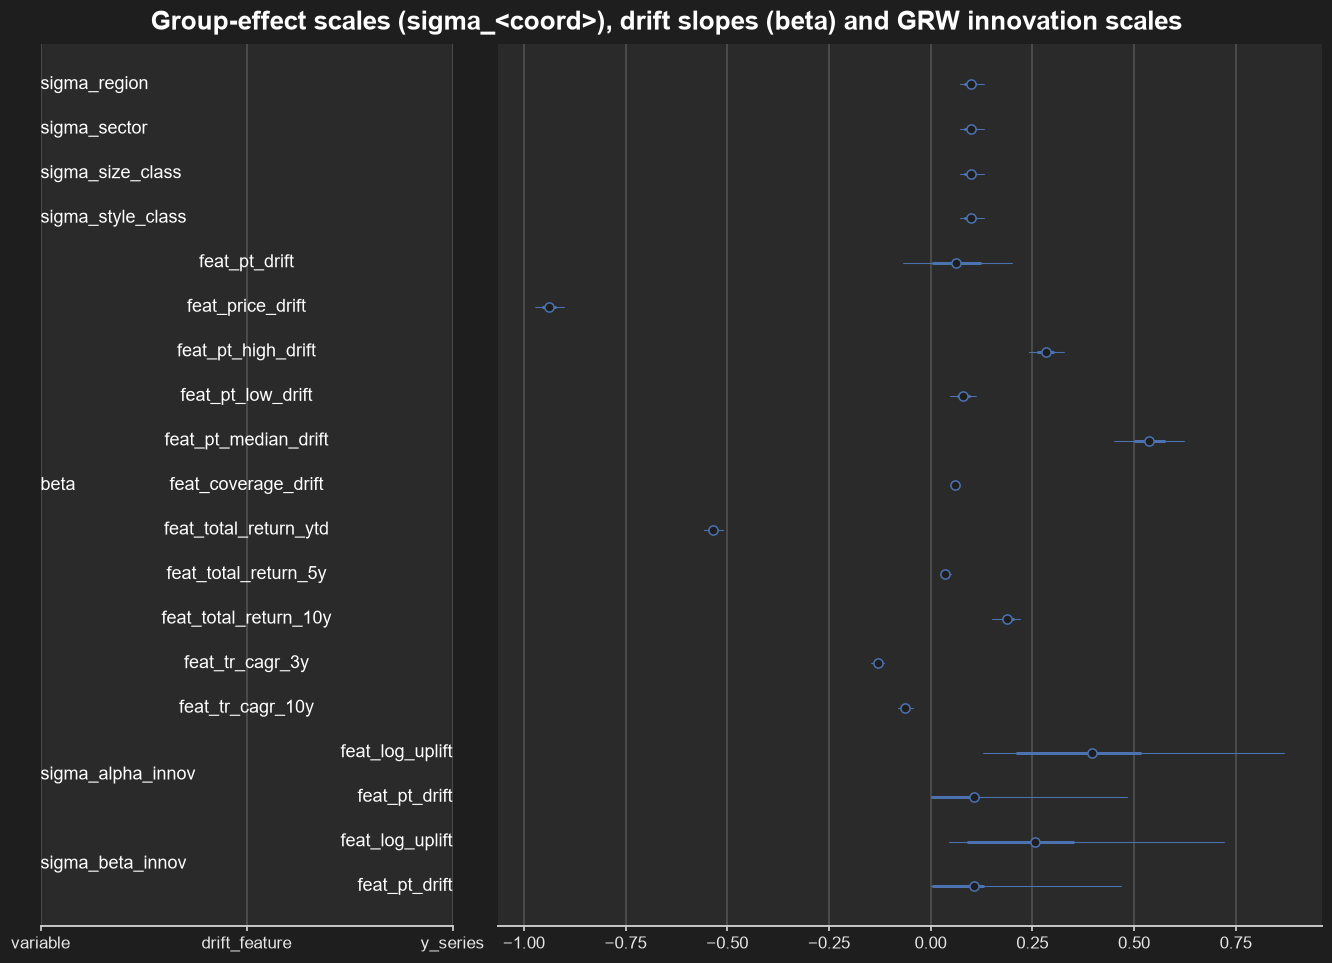

In [11]:
run_diagnostics(idata, panel)

## §10 — Expected price targets: posterior screen & export

- `summarize_panel_screen` → a `ScreenContext` carrying the posterior `expected_upside`
  (`eu`) and `expected_pt` (`ept`) draws over `(chain, draw, isin)`, the per-ISIN
  screening `results` table (sorted by expected upside), and the structural-TS
  Monte-Carlo `mc_summary`.
- `expected_pt` is reconstructed multiplicatively from the de-standardised log-uplift
  baseline (`last_price · exp(log_uplift)`), so it — and its 94 % HDI band — is positive
  by construction.
- The `mc_summary` `er_*` columns are genuine **decimal returns**: the latent
  `risk_adj_return` / `sigma_isin` are de-standardised onto the log-uplift scale before
  the simulation, then `expm1`-mapped, so `prob_pos = P(return > 0)` (not P(beats the
  cross-sectional average upside)).
- The per-ISIN `results` table also surfaces the realised-return drift inputs as reporting
  columns — `total_return_ytd_pct`, `total_return_5y_pct`, `total_return_10y_pct`,
  `tr_cagr_3y_pct`, `tr_cagr_10y_pct` — next to the posterior `expected_upside_pct` so the
  smoothed expectation can be read against realised momentum.

`export_analytics` de-standardises the screen and (when `write=True`) appends one row per
ISIN to `analytics.kalman_filtered_price_targets`, mapping the fused MvGRW +
systematic-risk-conditioned posterior onto the table's Kalman columns:

| analytics column                                   | source (fused posterior)                                            |
|----------------------------------------------------|---------------------------------------------------------------------|
| `price_target_kalman` / `kalman_estimate`          | posterior-mean `expected_pt` (de-standardised smoothed target)      |
| `kalman_variance`                                  | posterior variance of `expected_pt`                                 |
| `implied_return_kalman` / `expected_upside_kalman` | posterior-mean `expected_upside` (decimal)                          |
| `kalman_gain`                                      | logit-normal `achieve_prob` (smoother confidence analogue)          |
| `signal_strength`                                  | `\|E[risk_adj_return]\| / sd(risk_adj_return)` (conviction z-score) |
| `cvar_book_weight`                                 | normalised long-book weight (held names sum to 1 / 100 % gross)     |
| `cvar_5pct_kalman`                                 | per-name 5 % expected shortfall (CVaR) of the upside draws          |
| `reward_to_cvar`                                   | STARR ratio (expected upside / binding tail risk) used for sizing   |

The §10b CVaR sizing is computed once by `compute_cvar_aware_book` and shared with the
§14b recommendations, so the export and the screen agree exactly. Set `write=True` to
append via `export_to_analytics_db` (`DB_ANALYTICS_SCHEMA`, default `analytics`).

Fused-panel screen for 6233 ISINs (MC horizon=4, rho=0.85).


,isin,ticker,name,region,country,unit,exchange,sector,industry,size_class,...,total_return_5y_pct,total_return_10y_pct,tr_cagr_3y_pct,tr_cagr_10y_pct,n_analysts,er_mean,er_p05,er_p50,er_p95,mc_prob_pos
0,ARP432631215,PAMP,Pampa Energía S.A.,Latin America and Caribbean,AR,ARS,BASE,Utilities,Electric Utilities,Small Cap,...,4616.04,35326.62,83.74,79.71,3.0,3.104969,1.973445,3.073884,4.281127,0.999667
1,US0381692070,APLD,Applied Digital Corporation,United States and Canada,US,USD,NasdaqGS,Information Technology,IT Services,Mid Cap,...,547.08,64609.23,73.05,90.93,11.0,2.925490,2.017398,2.919771,3.872921,0.999917
2,CH0363463438,IDIA,Idorsia Ltd,Europe,CH,CHF,SWX,Health Care,Biotechnology,Small Cap,...,-78.19,NaN,-11.64,NaN,3.0,2.815632,2.062326,2.775121,3.637580,0.999792
3,US9290332074,VOR,Vor Biopharma Inc.,United States and Canada,US,USD,NasdaqGS,Health Care,Biotechnology,Small Cap,...,-96.53,NaN,-47.63,NaN,8.0,2.547242,1.839264,2.512966,3.326530,1.000000
4,ARP9897X1319,YPFD,YPF Sociedad Anónima,Latin America and Caribbean,AR,ARS,BASE,Energy,Oil Gas and Consumable Fuels,Large Cap,...,8912.91,28581.21,117.41,75.96,3.0,2.562895,1.544974,2.503849,3.706894,0.999583
5,US75955J4022,RLMD,Relmada Therapeutics Inc.,United States and Canada,US,USD,NasdaqCM,Health Care,Pharmaceuticals,Small Cap,...,-78.22,-39.04,37.18,-4.83,6.0,2.528972,1.777284,2.485852,3.385058,0.999708
6,CNE100006QF7,2432,Shenzhen Dobot Corp Ltd,Asia / Pacific,CN,HKD,SEHK,Industrials,Machinery,Small Cap,...,NaN,NaN,NaN,NaN,7.0,2.237364,1.726105,2.218662,2.813907,0.999833
7,KYG622681008,1860,Mobvista Inc.,Asia / Pacific,SG,HKD,SEHK,Communication Services,Media,Small Cap,...,56.23,NaN,51.57,NaN,3.0,2.263088,1.233890,2.151898,3.403643,0.998458
8,BRBHIAACNOR1,BHIA3,Grupo Casas Bahia S.A.,Latin America and Caribbean,BR,BRL,BOVESPA,Consumer Discretionary,Specialty Retail,Small Cap,...,-99.70,-98.27,-74.04,-33.31,7.0,2.206371,0.997294,2.067911,3.664462,0.996625
9,US09077V1008,BIOA,BioAge Labs Inc.,United States and Canada,US,USD,NasdaqGS,Health Care,Pharmaceuticals,Small Cap,...,NaN,NaN,NaN,NaN,8.0,1.808728,1.251786,1.774564,2.434089,0.999792


C:\Users\markm\PML_Finance_Project\pymc_kalman_filter_pt.py:2046: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


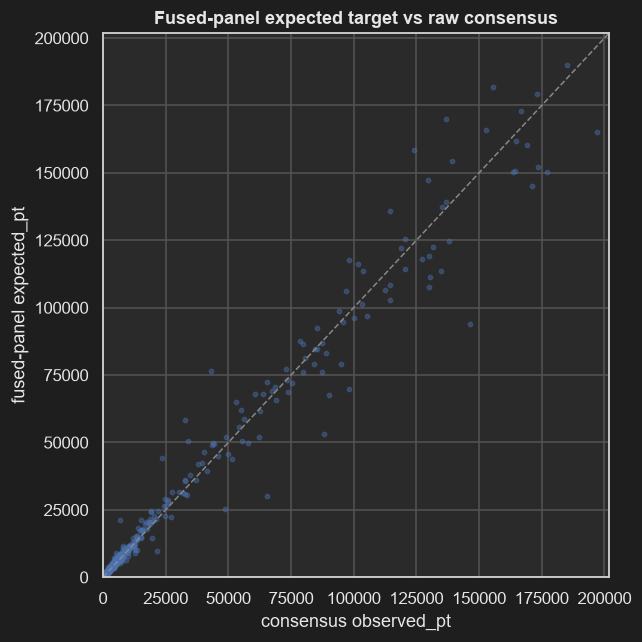

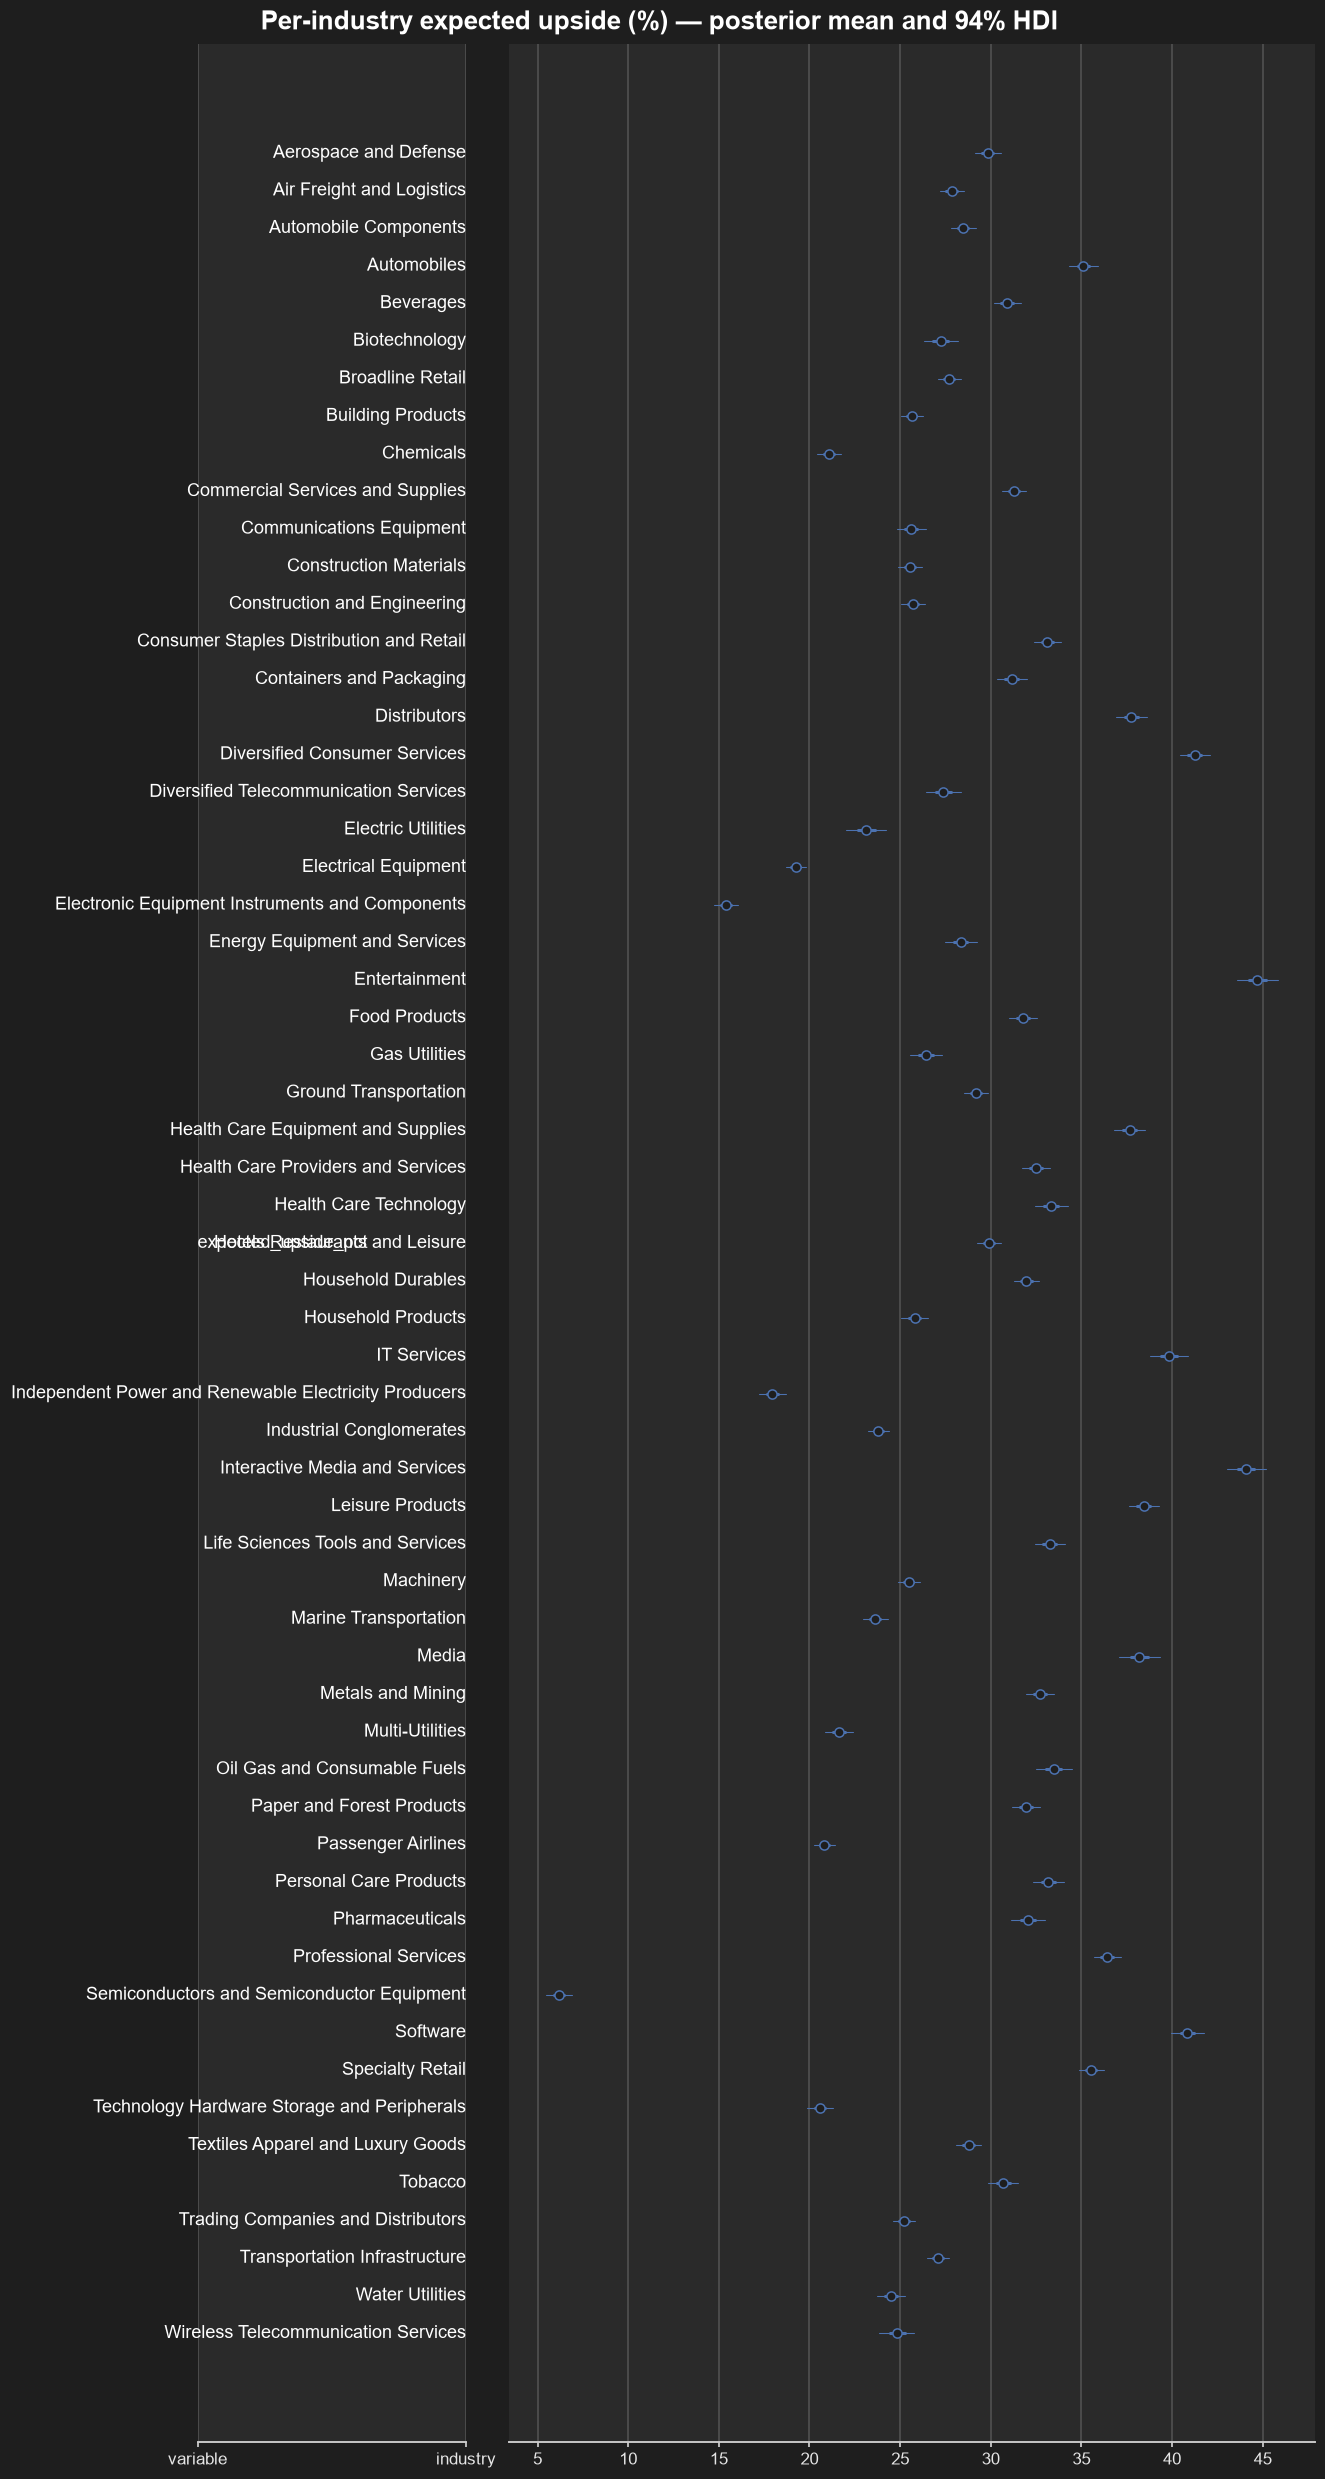

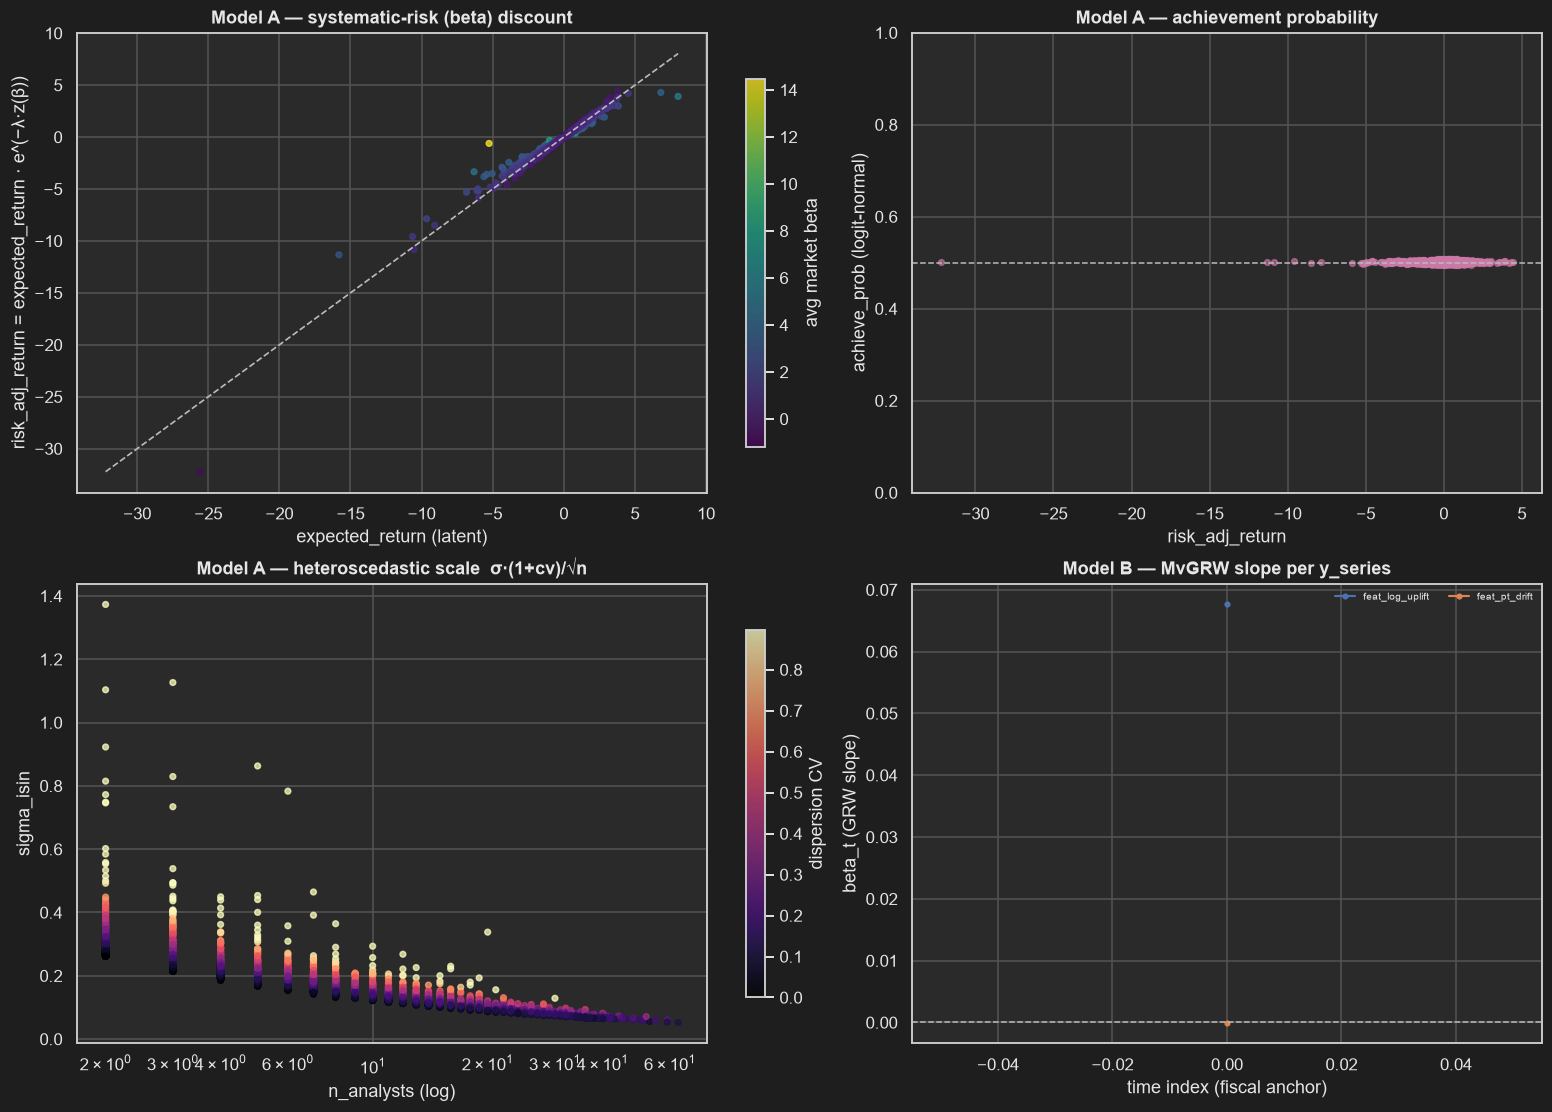

C:\Users\markm\PML_Finance_Project\pymc_kalman_filter_pt.py:2163: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


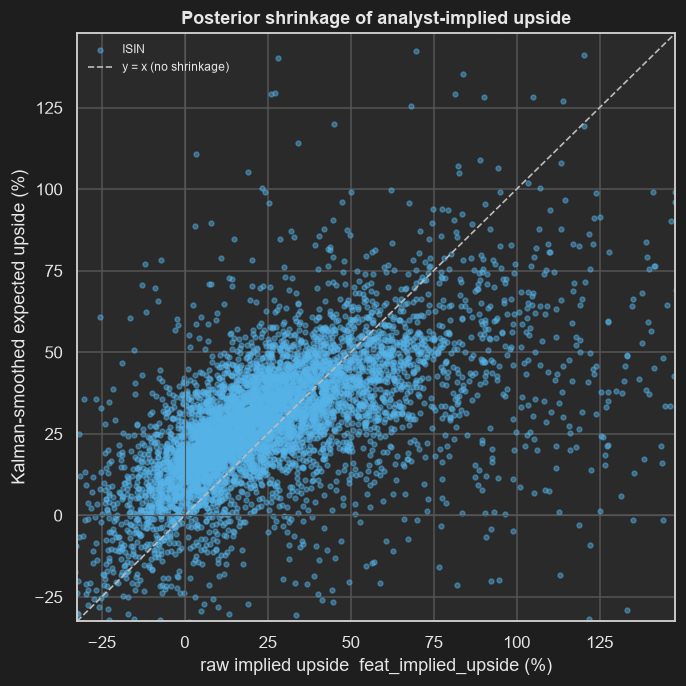

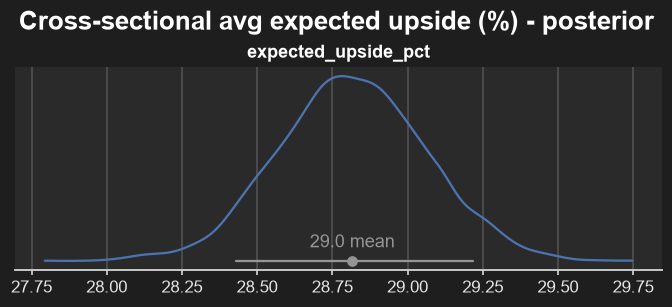

C:\Users\markm\PML_Finance_Project\pymc_kalman_filter_pt.py:2193: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


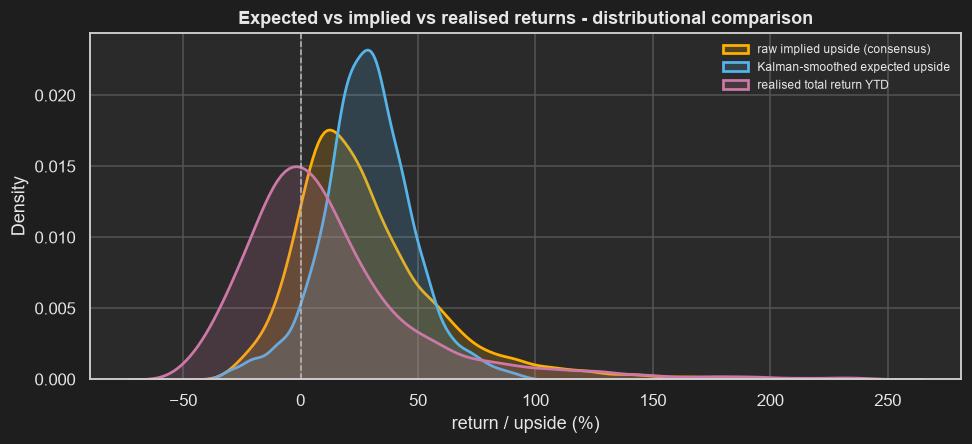

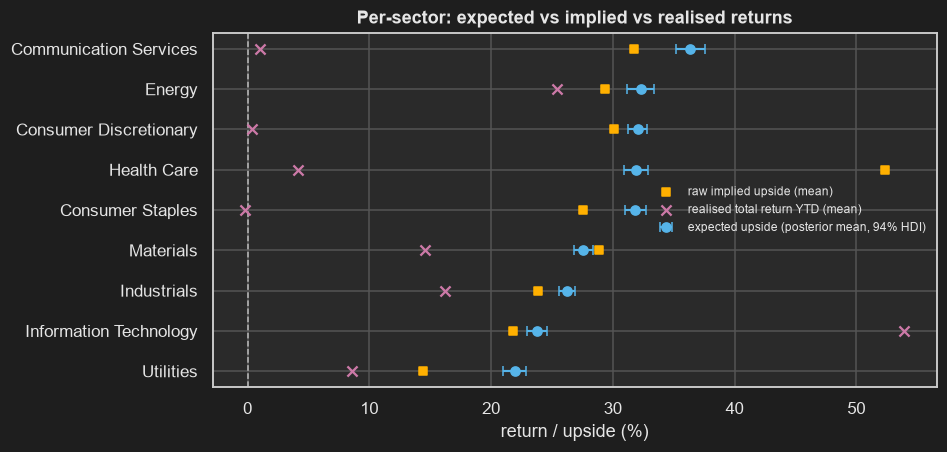

,isin,ticker,name,region,country,unit,exchange,sector,industry,size_class,...,total_return_5y_pct,total_return_10y_pct,tr_cagr_3y_pct,tr_cagr_10y_pct,n_analysts,er_mean,er_p05,er_p50,er_p95,mc_prob_pos
0,ARP432631215,PAMP,Pampa Energía S.A.,Latin America and Caribbean,AR,ARS,BASE,Utilities,Electric Utilities,Small Cap,...,4616.04,35326.62,83.74,79.71,3.0,3.104969,1.973445,3.073884,4.281127,0.999667
1,US0381692070,APLD,Applied Digital Corporation,United States and Canada,US,USD,NasdaqGS,Information Technology,IT Services,Mid Cap,...,547.08,64609.23,73.05,90.93,11.0,2.925490,2.017398,2.919771,3.872921,0.999917
2,CH0363463438,IDIA,Idorsia Ltd,Europe,CH,CHF,SWX,Health Care,Biotechnology,Small Cap,...,-78.19,NaN,-11.64,NaN,3.0,2.815632,2.062326,2.775121,3.637580,0.999792
3,US9290332074,VOR,Vor Biopharma Inc.,United States and Canada,US,USD,NasdaqGS,Health Care,Biotechnology,Small Cap,...,-96.53,NaN,-47.63,NaN,8.0,2.547242,1.839264,2.512966,3.326530,1.000000
4,ARP9897X1319,YPFD,YPF Sociedad Anónima,Latin America and Caribbean,AR,ARS,BASE,Energy,Oil Gas and Consumable Fuels,Large Cap,...,8912.91,28581.21,117.41,75.96,3.0,2.562895,1.544974,2.503849,3.706894,0.999583
5,US75955J4022,RLMD,Relmada Therapeutics Inc.,United States and Canada,US,USD,NasdaqCM,Health Care,Pharmaceuticals,Small Cap,...,-78.22,-39.04,37.18,-4.83,6.0,2.528972,1.777284,2.485852,3.385058,0.999708
6,CNE100006QF7,2432,Shenzhen Dobot Corp Ltd,Asia / Pacific,CN,HKD,SEHK,Industrials,Machinery,Small Cap,...,NaN,NaN,NaN,NaN,7.0,2.237364,1.726105,2.218662,2.813907,0.999833
7,KYG622681008,1860,Mobvista Inc.,Asia / Pacific,SG,HKD,SEHK,Communication Services,Media,Small Cap,...,56.23,NaN,51.57,NaN,3.0,2.263088,1.233890,2.151898,3.403643,0.998458
8,BRBHIAACNOR1,BHIA3,Grupo Casas Bahia S.A.,Latin America and Caribbean,BR,BRL,BOVESPA,Consumer Discretionary,Specialty Retail,Small Cap,...,-99.70,-98.27,-74.04,-33.31,7.0,2.206371,0.997294,2.067911,3.664462,0.996625
9,US09077V1008,BIOA,BioAge Labs Inc.,United States and Canada,US,USD,NasdaqGS,Health Care,Pharmaceuticals,Small Cap,...,NaN,NaN,NaN,NaN,8.0,1.808728,1.251786,1.774564,2.434089,0.999792


In [12]:
screen = summarize_panel_screen(idata, panel)
results = screen.results
results.head(15)

In [13]:
# Set write=True to persist to analytics.kalman_filtered_price_targets.
kalman_results = export_analytics(idata, panel, screen, write=False)
kalman_results.head()

Built kalman_filtered_price_targets row-set: (6233, 19)  (CVaR-aware book: 25 sized names, gross=100%).


,isin,ticker,name,country,exchange,sector,industry,implied_return_kalman,expected_upside_kalman,price_target_kalman,kalman_estimate,kalman_variance,kalman_gain,signal_strength,original_price,original_target,cvar_book_weight,cvar_5pct_kalman,reward_to_cvar
1658,US03945R1023,ACHR,Archer Aviation Inc.,US,NYSE,Industrials,Aerospace and Defense,0.4709,0.4709,8.1929,8.1929,0.0009,0.5042,44.1732,5.570,10.6111,0.0442,45.9679,41.9565
1858,US8361001071,SOUN,SoundHound AI Inc.,US,NasdaqGM,Information Technology,Software,0.5199,0.5199,10.8216,10.8216,0.0019,0.5014,49.0634,7.120,14.0000,0.0439,50.7427,41.7116
3535,GB0001859296,VTY,Vistry Group PLC,GB,LSE,Consumer Discretionary,Household Durables,0.5783,0.5783,3.8257,3.8257,0.0003,0.5018,51.1151,2.424,3.4117,0.0421,56.3808,39.9754
1937,US89377M1099,TMDX,TransMedics Group Inc.,US,NasdaqGM,Health Care,Health Care Equipment and Supplies,0.5688,0.5688,123.6088,123.6088,0.3115,0.5024,50.7596,78.790,117.3333,0.0415,55.4391,39.3698
3279,DE0006219934,JUN3,Jungheinrich Aktiengesellschaft,DE,XTRA,Industrials,Machinery,0.4867,0.4867,35.8298,35.8298,0.0216,0.5027,42.7723,24.100,36.5000,0.0412,47.4284,39.1579
39,US0239391016,AMTM,Amentum Holdings Inc.,US,NYSE,Industrials,Professional Services,0.5798,0.5798,34.2181,34.2181,0.0250,0.5030,51.1458,21.660,33.5000,0.0412,56.4970,39.1451
1746,US4500561067,IRTC,iRhythm Holdings Inc.,US,NasdaqGS,Health Care,Health Care Equipment and Supplies,0.8719,0.8719,195.8954,195.8954,1.3174,0.5049,69.2598,104.650,178.9286,0.0407,84.9324,38.6031
2826,CH0276534614,ZEHN,Zehnder Group AG,CH,SWX,Industrials,Building Products,0.5848,0.5848,100.3204,100.3204,0.2147,0.4994,51.8118,63.300,86.3252,0.0406,56.9665,38.5397
273,CH0006372897,INRN,Interroll Holding AG,CH,SWX,Industrials,Machinery,0.5319,0.5319,2114.0905,2114.0905,85.7072,0.5002,46.9021,1380.000,2257.1429,0.0405,51.8126,38.4801
3899,NL0015000GX8,ENVI,Envipco Holding N.V.,NL,ENXTAM,Industrials,Machinery,0.6330,0.6330,6.2054,6.2054,0.0010,0.4980,53.0278,3.800,8.0500,0.0399,61.6287,37.9009


write=False -> not persisted. Pass write=True to append to the DB sink.


,isin,ticker,name,country,exchange,sector,industry,implied_return_kalman,expected_upside_kalman,price_target_kalman,kalman_estimate,kalman_variance,kalman_gain,signal_strength,original_price,original_target,cvar_book_weight,cvar_5pct_kalman,reward_to_cvar
0,US67066G1040,NVDA,NVIDIA Corporation,US,NasdaqGS,Information Technology,Semiconductors and Semiconductor Equipment,0.877387,0.877387,395.546763,395.546763,273.106883,0.501778,9.398841,210.69,298.9322,0.0,66.688272,4.168018
1,IE000GID8VI0,GHRS,GH Research PLC,IE,NasdaqGM,Health Care,Pharmaceuticals,0.054764,0.054764,23.457954,23.457954,0.025070,0.504049,24.876464,22.24,39.5000,0.0,4.054021,0.483441
2,US36266G1076,GEHC,GE HealthCare Technologies Inc.,US,NasdaqGS,Health Care,Health Care Equipment and Supplies,0.413729,0.413729,87.071559,87.071559,0.169042,0.501985,26.489295,61.59,79.7222,0.0,40.009657,30.349243
3,US0420682058,ARM,Arm Holdings plc,GB,NasdaqGS,Information Technology,Semiconductors and Semiconductor Equipment,-0.304483,-0.304483,305.651926,305.651926,10.337400,0.500299,55.586018,439.46,278.2900,0.0,-31.878210,-0.867391
4,US02079K3059,GOOGL,Alphabet Inc.,US,NasdaqGS,Communication Services,Interactive Media and Services,0.245146,0.245146,458.250954,458.250954,7.018944,0.501790,0.330119,368.03,432.8345,0.0,23.001055,16.197165


## §11 — Single-ISIN time-series Kalman filter (+ §11b stochastic volatility)

§1–§10 are the **cross-sectional** panel: one row per ISIN, no real time axis. This
section switches to the **literal** single-security `GaussianRandomWalk` filter from
`KalmanFilterModel.py` to recover the quantity this model exists for — a **price target
evolving over time** with a credible band.

`run_single_isin_filter` reconstructs the time axis from the embedded `*_ago`
price-target cohort (`price_target_1w_ago`, `price_target_high_3m_ago`,
`price_target_median_1y_ago`, …), unpivoted via `build_price_target_history()` into a
`(isin, asof_date, price_target)` panel and **anchored on `income_statement_report_date`**
so the axis tracks the real reporting cadence. It picks the cohort name with the richest
history (most-recent earnings, largest market cap, ≥ 2 `*_ago` observations).

Because that cohort is short (~6–16 points) and **irregularly spaced** (1w, 1m, 3m, 6m,
1y) — exactly where an explicit latent random walk funnels — the fit uses the funnel-free
**marginalized** parameterization with a **structural trend** (`trend=True`). The latent
path is integrated out analytically into a single `MvNormal` likelihood whose covariance
carries **both** the random-walk (process) and observation (measurement) variances,

$$\Sigma_{st} = P_0 + \sigma_{\text{state}}^2\,\min(\tau_s, \tau_t) + \sigma_{\text{obs}}^2\,\delta_{st},$$

with $\tau$ the **real elapsed time** (years) between observations (`_resolve_time_deltas`).
The observed log-targets enter *only* as the data (never as the mean), so $\sigma_{\text{state}}$
and $\sigma_{\text{obs}}$ are genuinely identified; the smoothed path is recovered as the
analytic Kalman/RTS smoother mean $\mathbb{E}[x\mid y]$ and rendered with
`plot_price_target_path()`. The fit then projects forward to the next fiscal events via
`KalmanFilterPriceTarget.forecast()`.

`run_single_isin_stochastic_vol` re-fits the **same** series with the opt-in latent
log-volatility random walk + robust Student-t observations (§11b). The cell is guarded —
it degrades to an informative message if `DB_URL` is unset or no ISIN carries ≥ 2 `*_ago`
observations.

Pulled pml.pml_df history frame: (20, 51)  (43 *_ago columns).
Fitting single-ISIN Kalman filter for CA01626P1484 (ATD) on 11 observations spanning 2021-02-01 – 2027-01-01.


NUTS[nutpie]: [sigma_state, sigma_obs, beta_trend, log_state_init]
INFO:pymc.sampling.mcmc:NUTS[nutpie]: [sigma_state, sigma_obs, beta_trend, log_state_init]


Output()

Marginalized GRW (+trend) fit: 11 obs, 6y span, divergences=0.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_state,0.0998,0.0342,0.0522,0.1591,4138.6293,3177.8868,1.0009,0.0005,0.0005
sigma_obs,0.0487,0.0209,0.0249,0.0862,5003.1044,3657.6125,1.0000,0.0003,0.0004
beta_trend,0.1049,0.0467,0.0334,0.1755,3633.0199,3285.8547,1.0012,0.0008,0.0009
log_state_init,3.8136,0.1445,3.5868,4.0435,6893.4671,4246.8434,1.0028,0.0017,0.0013


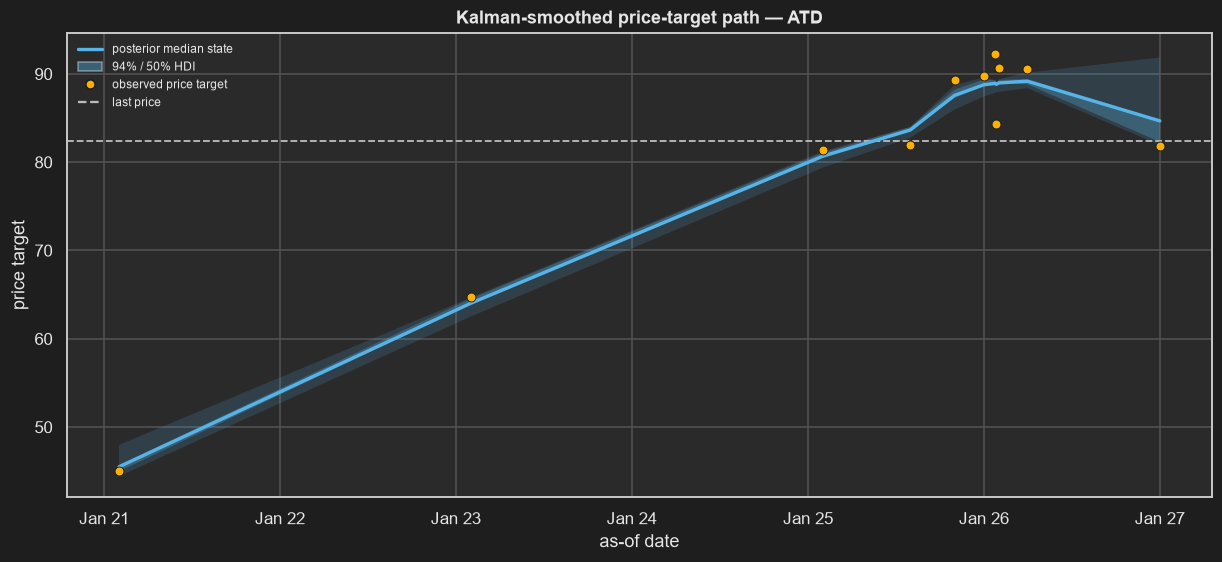

No future fiscal event beyond the last observation for CA01626P1484; forecast skipped.
SV realized-vol anchor (per-time): [25.5  25.5  25.5  25.5  25.5  25.5  25.48 25.48 25.48 25.44 18.95]


NUTS[nutpie]: [sigma_state, beta_trend, z_innov, vol_step_size, z_vol, vol_anchor_offset, nu_obs]
INFO:pymc.sampling.mcmc:NUTS[nutpie]: [sigma_state, beta_trend, z_innov, vol_step_size, z_vol, vol_anchor_offset, nu_obs]


Output()

Stochastic-volatility fit: 11 obs, divergences=0.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_state,0.0705,0.0265,0.0328,0.1145,730.1955,1177.4434,1.0005,0.0010,0.0010
vol_step_size,0.1019,0.1003,0.0055,0.3003,2286.3468,2076.9456,1.0010,0.0021,0.0027
nu_obs,12.0231,10.5567,1.8130,31.7874,4156.7712,2938.7465,1.0009,0.1472,0.2251
vol_anchor_offset,-3.0377,0.5232,-3.9204,-2.2405,1048.7114,1313.1643,1.0023,0.0164,0.0131
beta_trend,0.1315,0.0296,0.0850,0.1738,584.7524,837.7791,1.0120,0.0012,0.0014


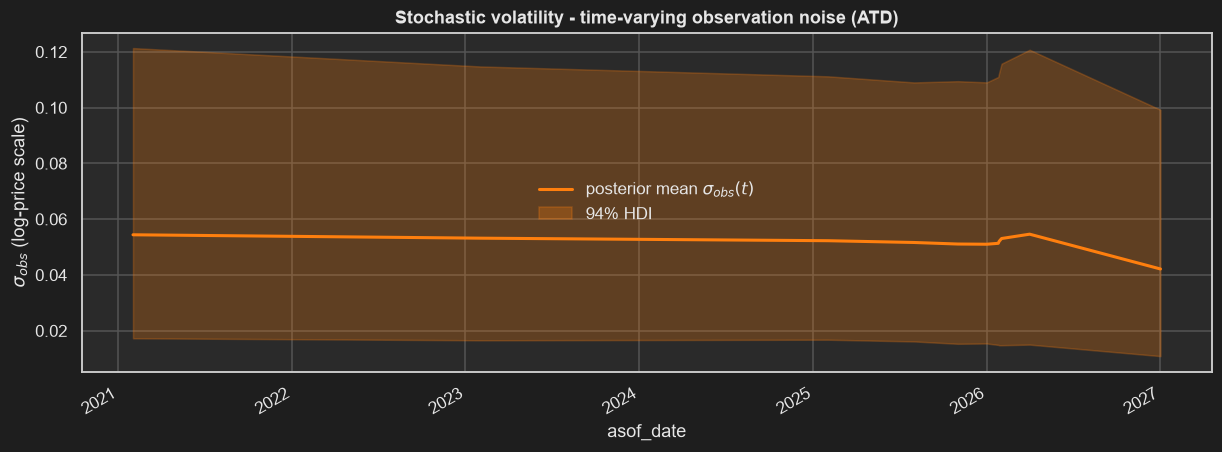

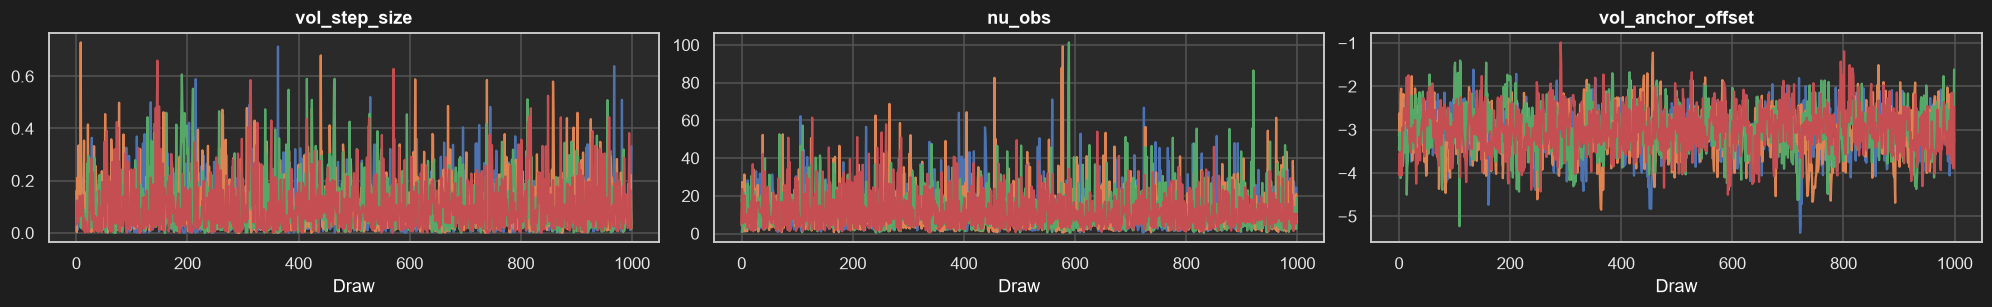

In [14]:
single_ctx = run_single_isin_filter(panel.frame, engine)
run_single_isin_stochastic_vol(single_ctx)

## §12 — Mingled-ISIN earnings-window cohort filter (+ §12b stochastic volatility)

Same state-space machinery as §11, but the time axis now represents an
**earnings-cohort consensus** rather than one security's history.
`run_mingled_cohort_filter` selects every ISIN whose `next_earnings` lands in the
**±10-day window** around today (`current_date ± INTERVAL '10 days'`, and on/after
2026-01-01), unpivots each name's `*_ago` cohort, and takes the cross-sectional
**median** price target at each shared `asof_date` — a single, time-ordered series of the
cohort consensus as it evolved across the earnings period.

The mingled series is again short and **irregularly spaced**, so it is fit with the same
funnel-free **marginalized** GRW (+ structural trend) whose `MvNormal` covariance carries
both the random-walk and observation variances scaled by real elapsed time. The three
quantities are compared on one axis: the posterior-mean Kalman-smoothed `expected_pt`
(with 94 % / 50 % HDI bands), the mingled cohort-median `observed_price_target`, and the
cohort-median `last_price` reference line.

`run_mingled_cohort_stochastic_vol` (§12b) re-fits with **stochastic volatility** — the
scalar `sigma_obs` replaced by a latent log-volatility random walk under a robust
Student-t likelihood, anchored on the **cohort-median** `feat_vol_{1m,3m,6m,1y}`
term-structure mapped onto the mingled `asof_date` grid by `build_realized_vol_path()`.
Both cells are guarded — they degrade cleanly when `DB_URL` is unset or the window yields
fewer than 2 mingled observations.

Recent-earnings window cohort: 229 rows / 229 ISINs (43 *_ago columns).
Fitting mingled-cohort Kalman filter on 171 consensus observations spanning 2019-12-31 ... 2027-01-01.


NUTS[nutpie]: [sigma_state, sigma_obs, beta_trend, log_state_init]
INFO:pymc.sampling.mcmc:NUTS[nutpie]: [sigma_state, sigma_obs, beta_trend, log_state_init]


Output()

Marginalized GRW (+trend) fit: 171 obs, 2558d span, divergences=0.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_state,0.1193,0.0639,0.0398,0.2358,4056.9266,2666.6031,1.0019,0.0010,0.0011
sigma_obs,2.2717,0.1236,2.0852,2.4784,4967.5310,3280.1588,1.0024,0.0018,0.0013
beta_trend,0.1023,0.1066,-0.0660,0.2729,3852.7327,2779.1761,0.9998,0.0017,0.0013
log_state_init,1.9320,0.7466,0.7349,3.1446,4319.7309,3215.0008,1.0005,0.0113,0.0081


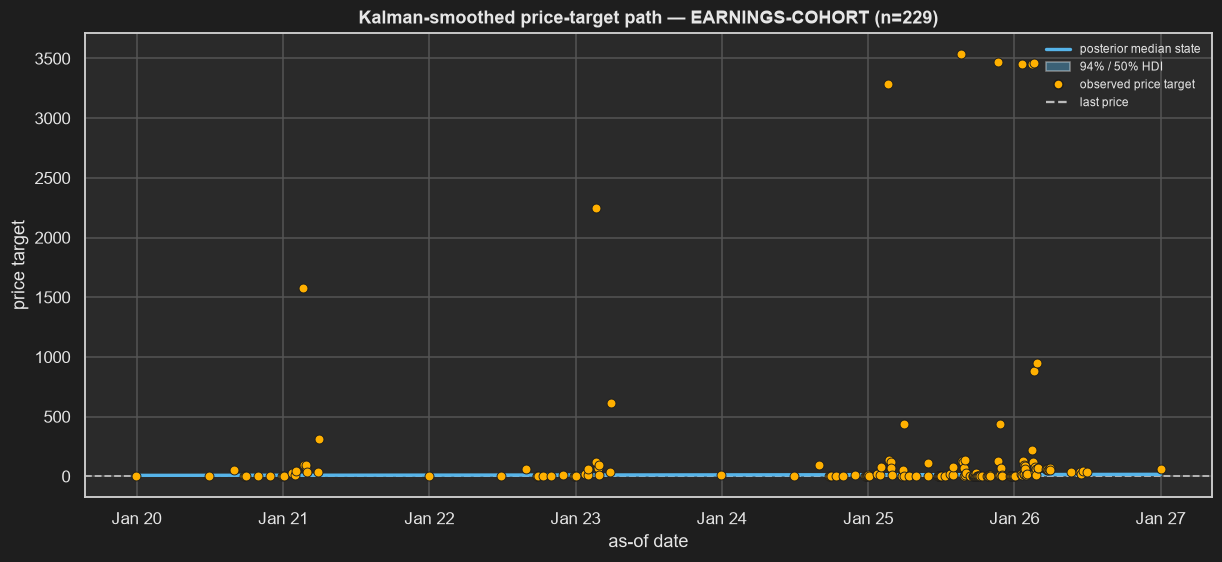

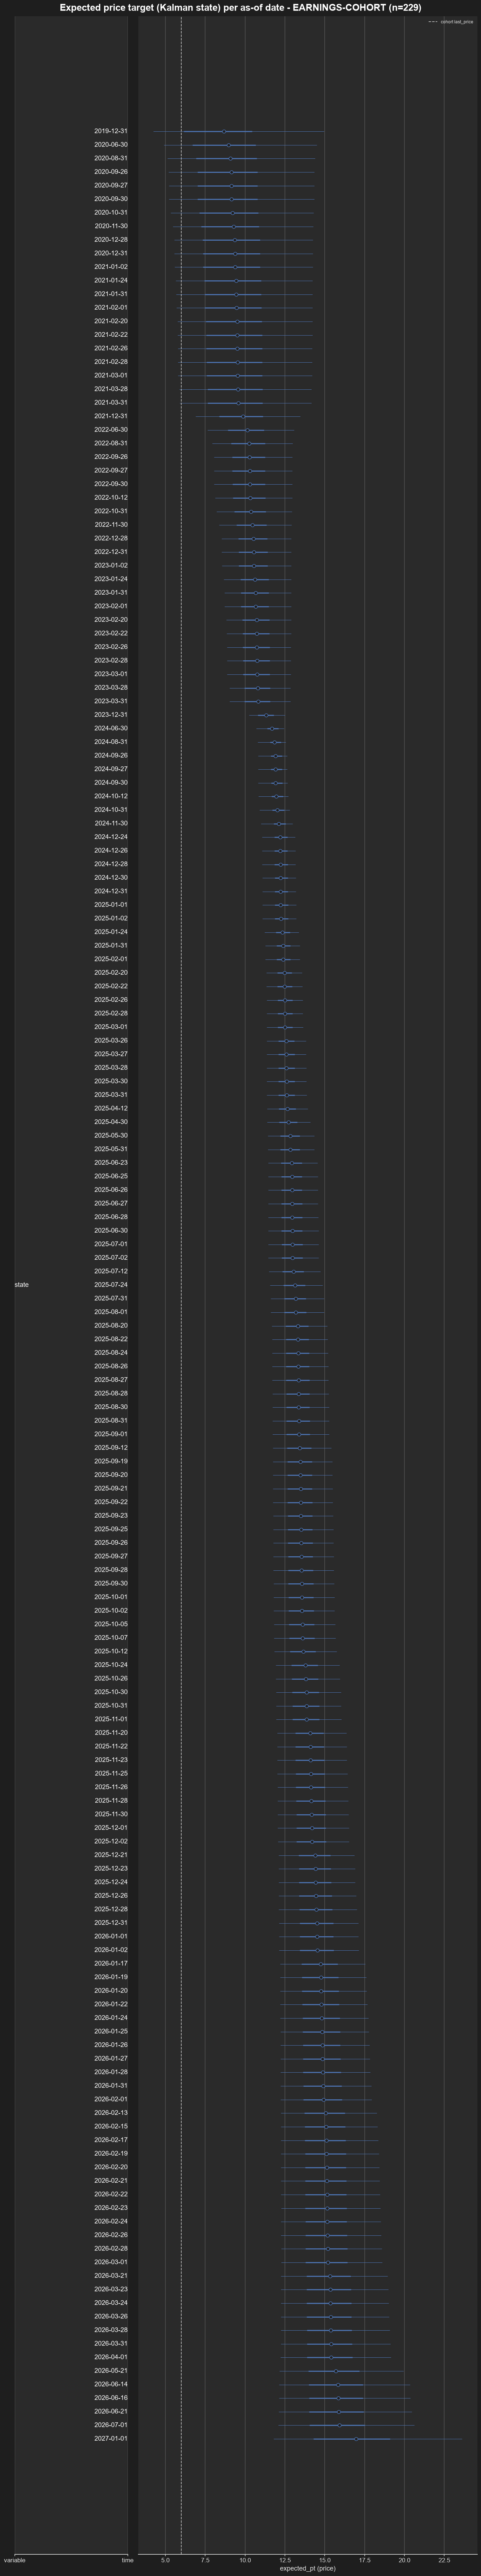

Mingled-cohort comparison (last_price vs observed_pt vs expected_pt):


,asof_date,n_isin,observed_pt,expected_pt,expected_pt_hdi_lo,expected_pt_hdi_hi,last_price,expected_vs_observed_pct
0,2019-12-31,2,5.779,8.666,3.772,17.141,6.0,49.969
1,2020-06-30,4,1.628,8.968,4.333,16.289,6.0,451.055
2,2020-08-31,1,49.900,9.089,4.545,16.079,6.0,-81.785
3,2020-09-26,1,4.020,9.137,4.640,15.996,6.0,127.297
4,2020-09-27,1,0.790,9.139,4.643,15.993,6.0,1056.871
...,...,...,...,...,...,...,...,...
166,2026-06-14,3,38.228,15.837,11.523,21.313,6.0,-58.572
167,2026-06-16,3,21.000,15.848,11.518,21.347,6.0,-24.531
168,2026-06-21,3,42.600,15.877,11.505,21.440,6.0,-62.731
169,2026-07-01,3,38.908,15.932,11.478,21.622,6.0,-59.053


Cohort SV realized-vol anchor (per-time): [46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.
 46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.
 46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.
 46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.
 46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.
 46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.
 46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.
 46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.
 46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.
 46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.
 46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.   46.
 46.   46.   45.99 45.9  45.89 45.88 45.87 45.86 45.85 45.84 45.84 45.83
 45.81 45.81 45.73 45.72 45.71 45.7  45.69 45.68 45.68 45.67 45.66 45.65
 45.64 45.63 45.51 45.5  45.49 

NUTS[nutpie]: [sigma_state, beta_trend, z_innov, vol_step_size, z_vol, vol_anchor_offset, nu_obs]
INFO:pymc.sampling.mcmc:NUTS[nutpie]: [sigma_state, beta_trend, z_innov, vol_step_size, z_vol, vol_anchor_offset, nu_obs]


Output()

Mingled-cohort stochastic-volatility fit: 171 obs, divergences=0.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_state,0.2987,0.0846,0.1771,0.4434,436.8904,877.7356,1.0150,0.0040,0.0028
vol_step_size,0.1201,0.0594,0.0361,0.2230,538.0050,892.0474,1.0046,0.0025,0.0018
nu_obs,11.1536,8.4444,3.5309,26.5126,3634.6832,3128.3177,1.0006,0.1483,0.2258
vol_anchor_offset,0.1896,0.3378,-0.3720,0.7004,2245.5120,2126.5783,1.0012,0.0072,0.0054
beta_trend,-0.3890,0.3115,-0.8956,0.0937,633.2503,879.6606,1.0058,0.0125,0.0088


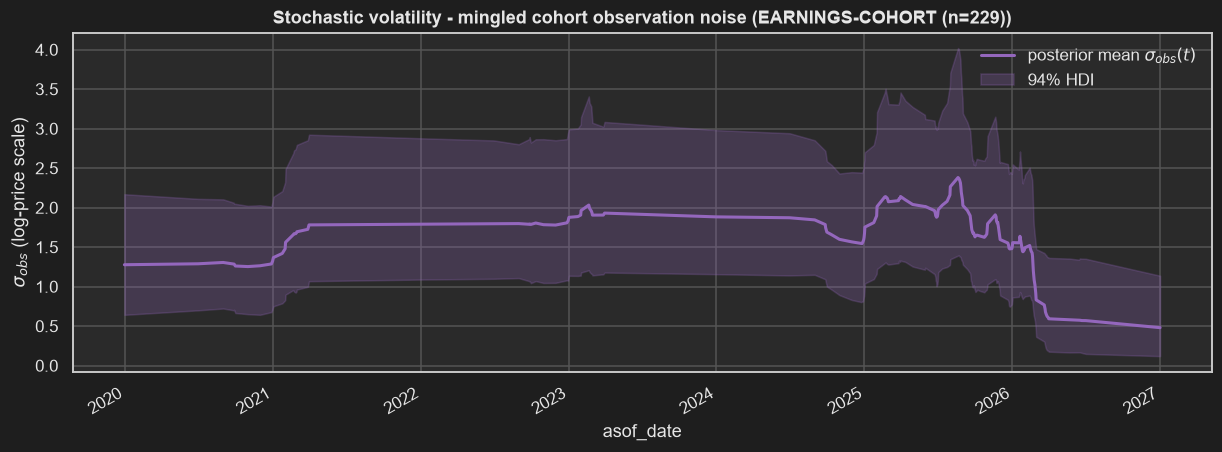

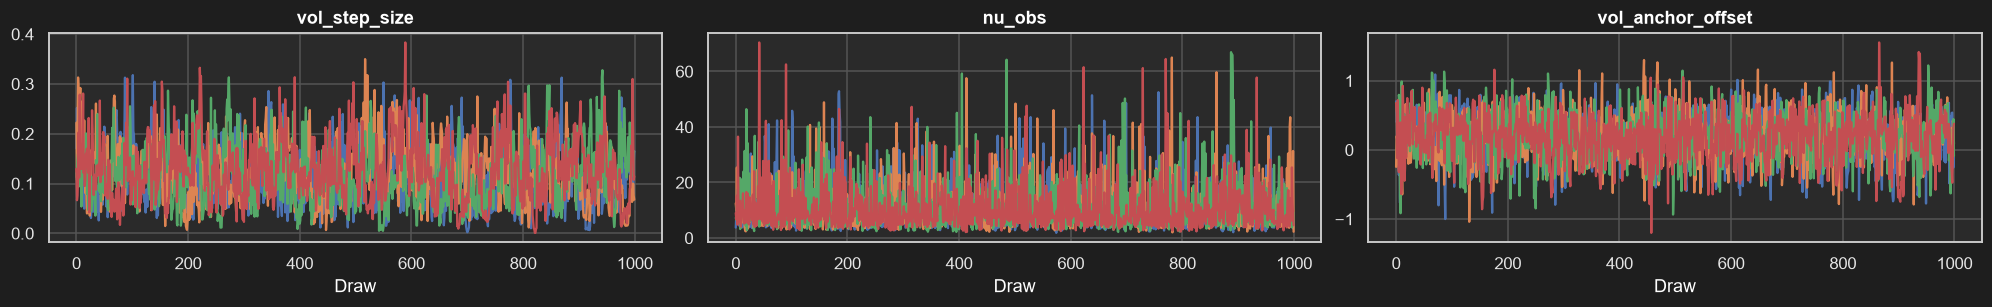

In [15]:
mingled_ctx = run_mingled_cohort_filter(panel.frame, engine)
run_mingled_cohort_stochastic_vol(panel.frame, mingled_ctx)

## §13 — Granular earnings-cohort posterior-predictive forest (+ §13.1 further views)

Where §12 **mingles** the ±10-day earnings cohort into one median series and refits, this
section keeps the same cohort but goes the other way: it stays **per-ISIN granular** and
**reuses the already-fitted cross-sectional posterior** from §5–§10 (no refit).

`run_granular_forest` de-standardises each cohort ISIN's posterior-predictive log-uplift
back to price units (`last_price · exp(log_uplift)`), giving a posterior-predictive
distribution of the *expected price* (the simulated analyst target) per name. These are
rendered as an `arviz_plots` **posterior-predictive forest** with the realised analyst
targets overlaid as observation points, plus two reference layers that turn it into a
screen: a **reference HDI band** (the pooled `expected_pt` 94 % / 50 % posterior region —
names whose interval sits entirely outside the 94 % band are the cohort's relative
outliers) and a **cohort `last_price` line** so the targets read as implied upside.

`run_granular_further_views` (§13.1) adds two complementary views: (a) the same forest
keyed off the stored §10 `results` HDI columns (cohort-median `expected_pt_hdi_lo … hi`),
and (b) a per-chain KDE of the cohort-average expected upside with a 0 % break-even line
(the chain overlay doubles as a soft convergence check). When the cohort is large the
forest caps to the most extreme names by expected upside (top/bottom 20) to keep one row
per ISIN legible; the truncation is announced. Both cells are guarded against an unset
`DB_URL` or an empty cohort overlap.

Recent-earnings cohort (next_earnings +/-10d): 229 ISINs.
Cohort ISINs overlapping the fitted posterior: 229.
Cohort has 229 ISINs; showing the 50 most extreme by expected upside (top/bottom 25).


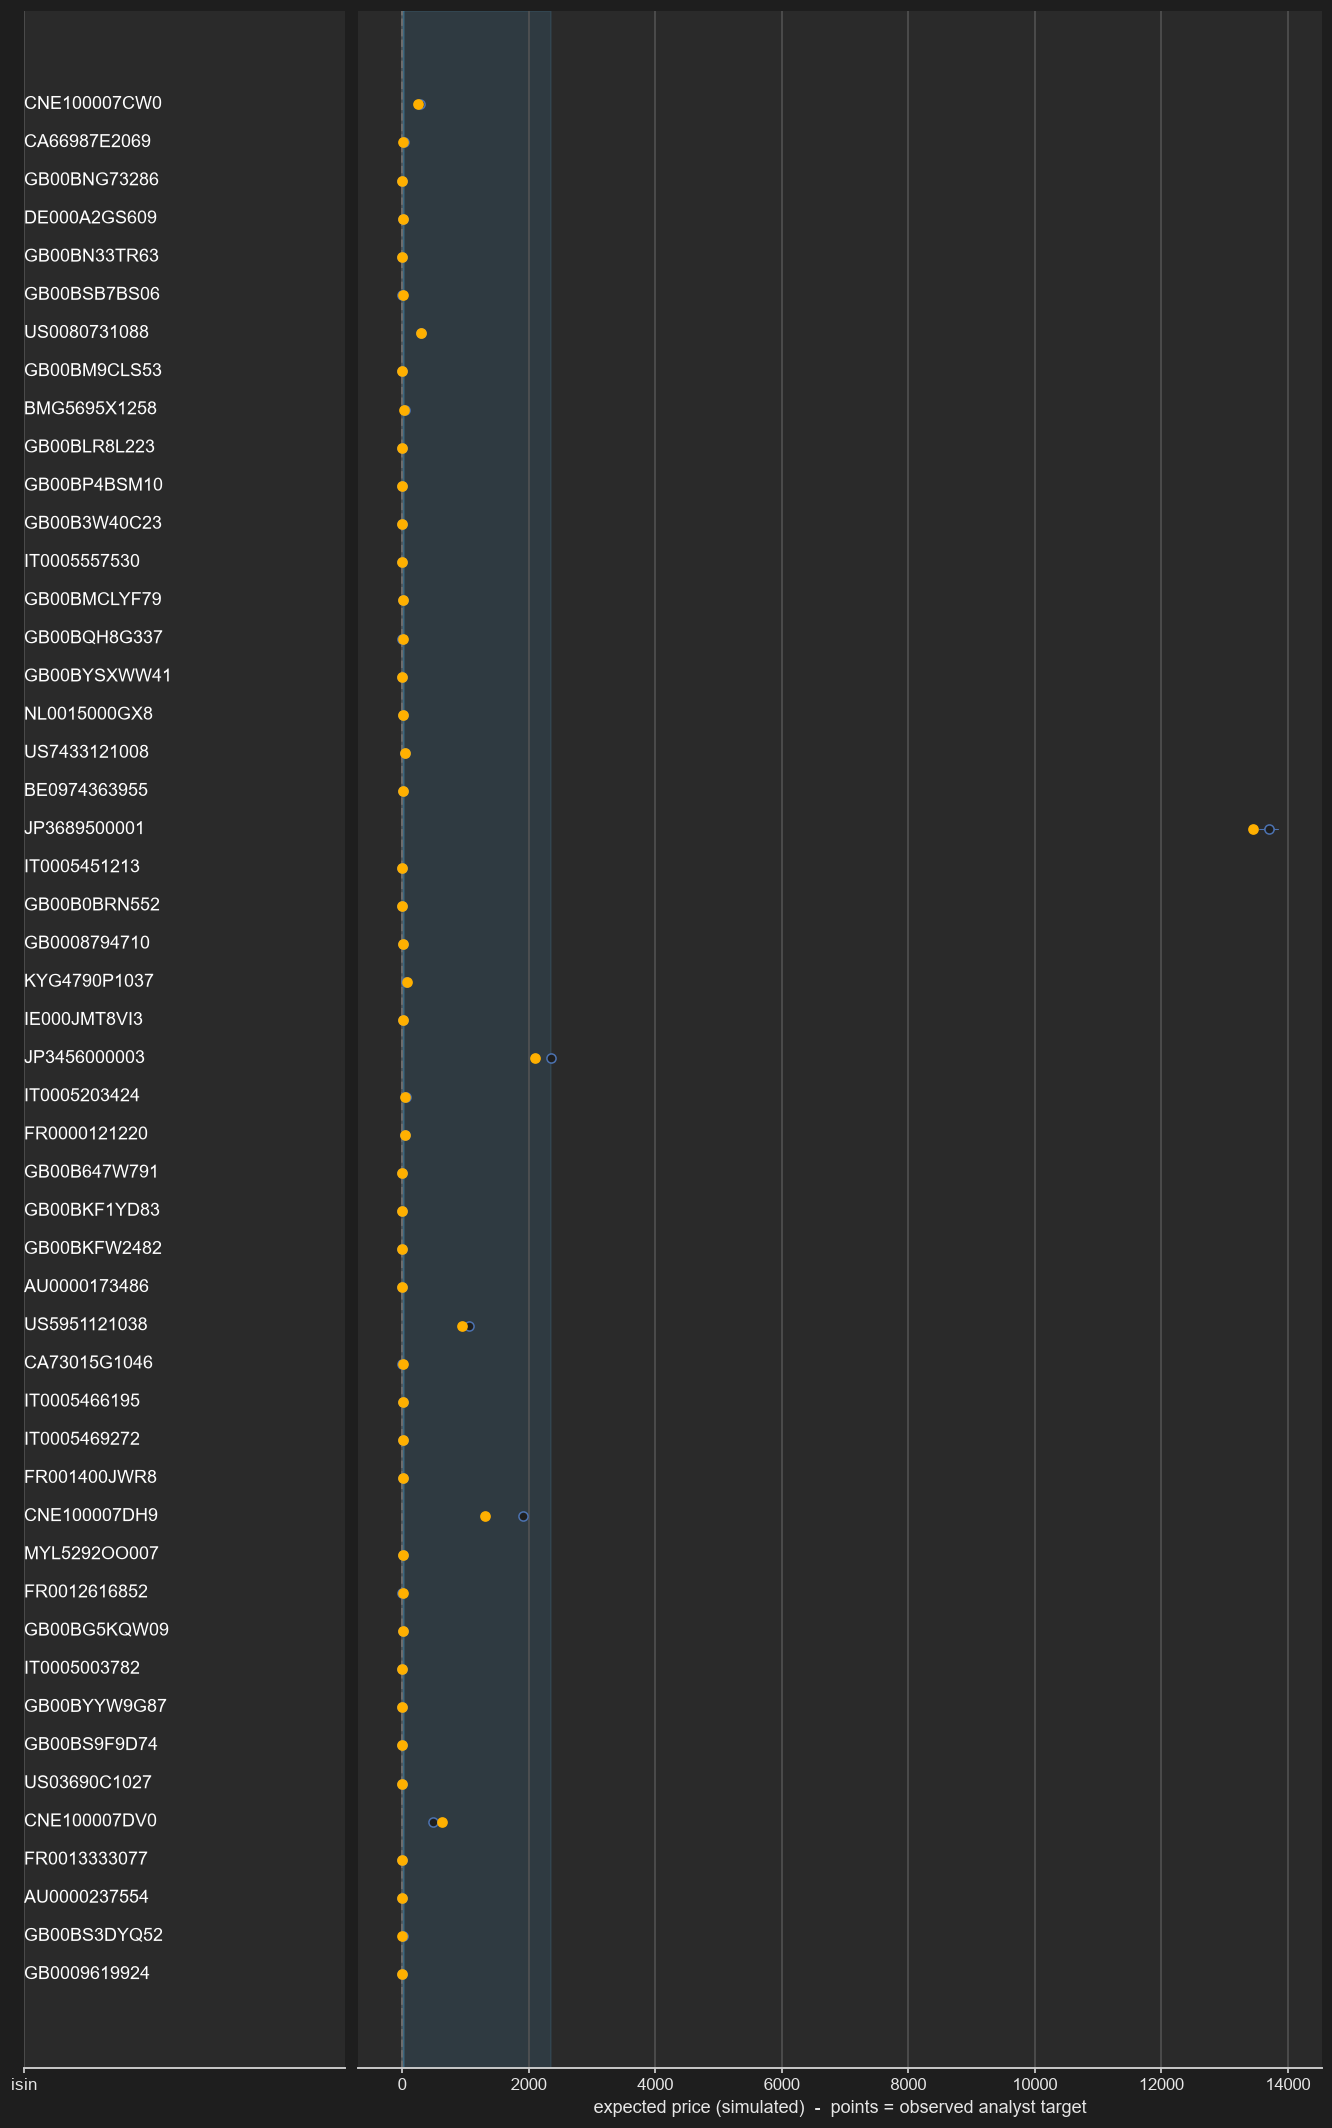

Cohort expected_pt 94% HDI band: (0.08, 2347.01);  50% HDI band: (0.93, 23.09);  cohort last_price ref = 4.66.


,isin,ticker,name,region,country,exchange,unit,sector,industry,last_price,observed_pt,expected_pt,expected_pt_hdi_lo,expected_pt_hdi_hi,expected_upside_pct
0,CNE100007CW0,3317,Shenzhen Xunce Technology Co. Ltd.,Asia / Pacific,CN,SEHK,HKD,Information Technology,IT Services,134.000,253.034,280.177,267.919,292.394,109.087
1,CA66987E2069,NG,NovaGold Resources Inc.,United States and Canada,CA,TSX,CAD,Materials,Metals and Mining,11.150,20.322,23.095,22.693,23.497,107.132
2,GB00BNG73286,AURR,Aurrigo International plc,Europe,GB,AIM,GBP,Consumer Discretionary,Automobile Components,0.710,1.750,1.351,1.324,1.379,90.352
3,DE000A2GS609,SB1,Smartbroker Holding AG,Europe,DE,XTRA,EUR,Communication Services,Interactive Media and Services,10.700,18.050,19.080,18.788,19.378,78.321
4,GB00BN33TR63,VINO,Virgin Wines UK PLC,Europe,GB,AIM,GBP,Consumer Staples,Consumer Staples Distribution and Retail,0.290,0.700,0.512,0.506,0.518,76.499
5,GB00BSB7BS06,PINE,Pinewood Technologies Group PLC,Europe,GB,LSE,GBP,Information Technology,Software,2.440,5.850,4.286,4.233,4.339,75.673
6,US0080731088,AVAV,AeroVironment Inc.,United States and Canada,US,NasdaqGS,USD,Industrials,Aerospace and Defense,169.610,301.119,293.151,289.661,296.887,72.838
7,GB00BM9CLS53,LORD,Lords Group Trading plc,Europe,GB,AIM,GBP,Industrials,Trading Companies and Distributors,0.162,0.480,0.278,0.274,0.282,71.265
8,BMG5695X1258,590,Luk Fook Holdings (International) Limited,Asia / Pacific,HK,SEHK,HKD,Consumer Discretionary,Specialty Retail,22.760,33.129,38.835,38.332,39.326,70.628
9,GB00BLR8L223,SAAS,Microlise Group plc,Europe,GB,AIM,GBP,Information Technology,Software,0.410,1.130,0.694,0.685,0.704,69.378


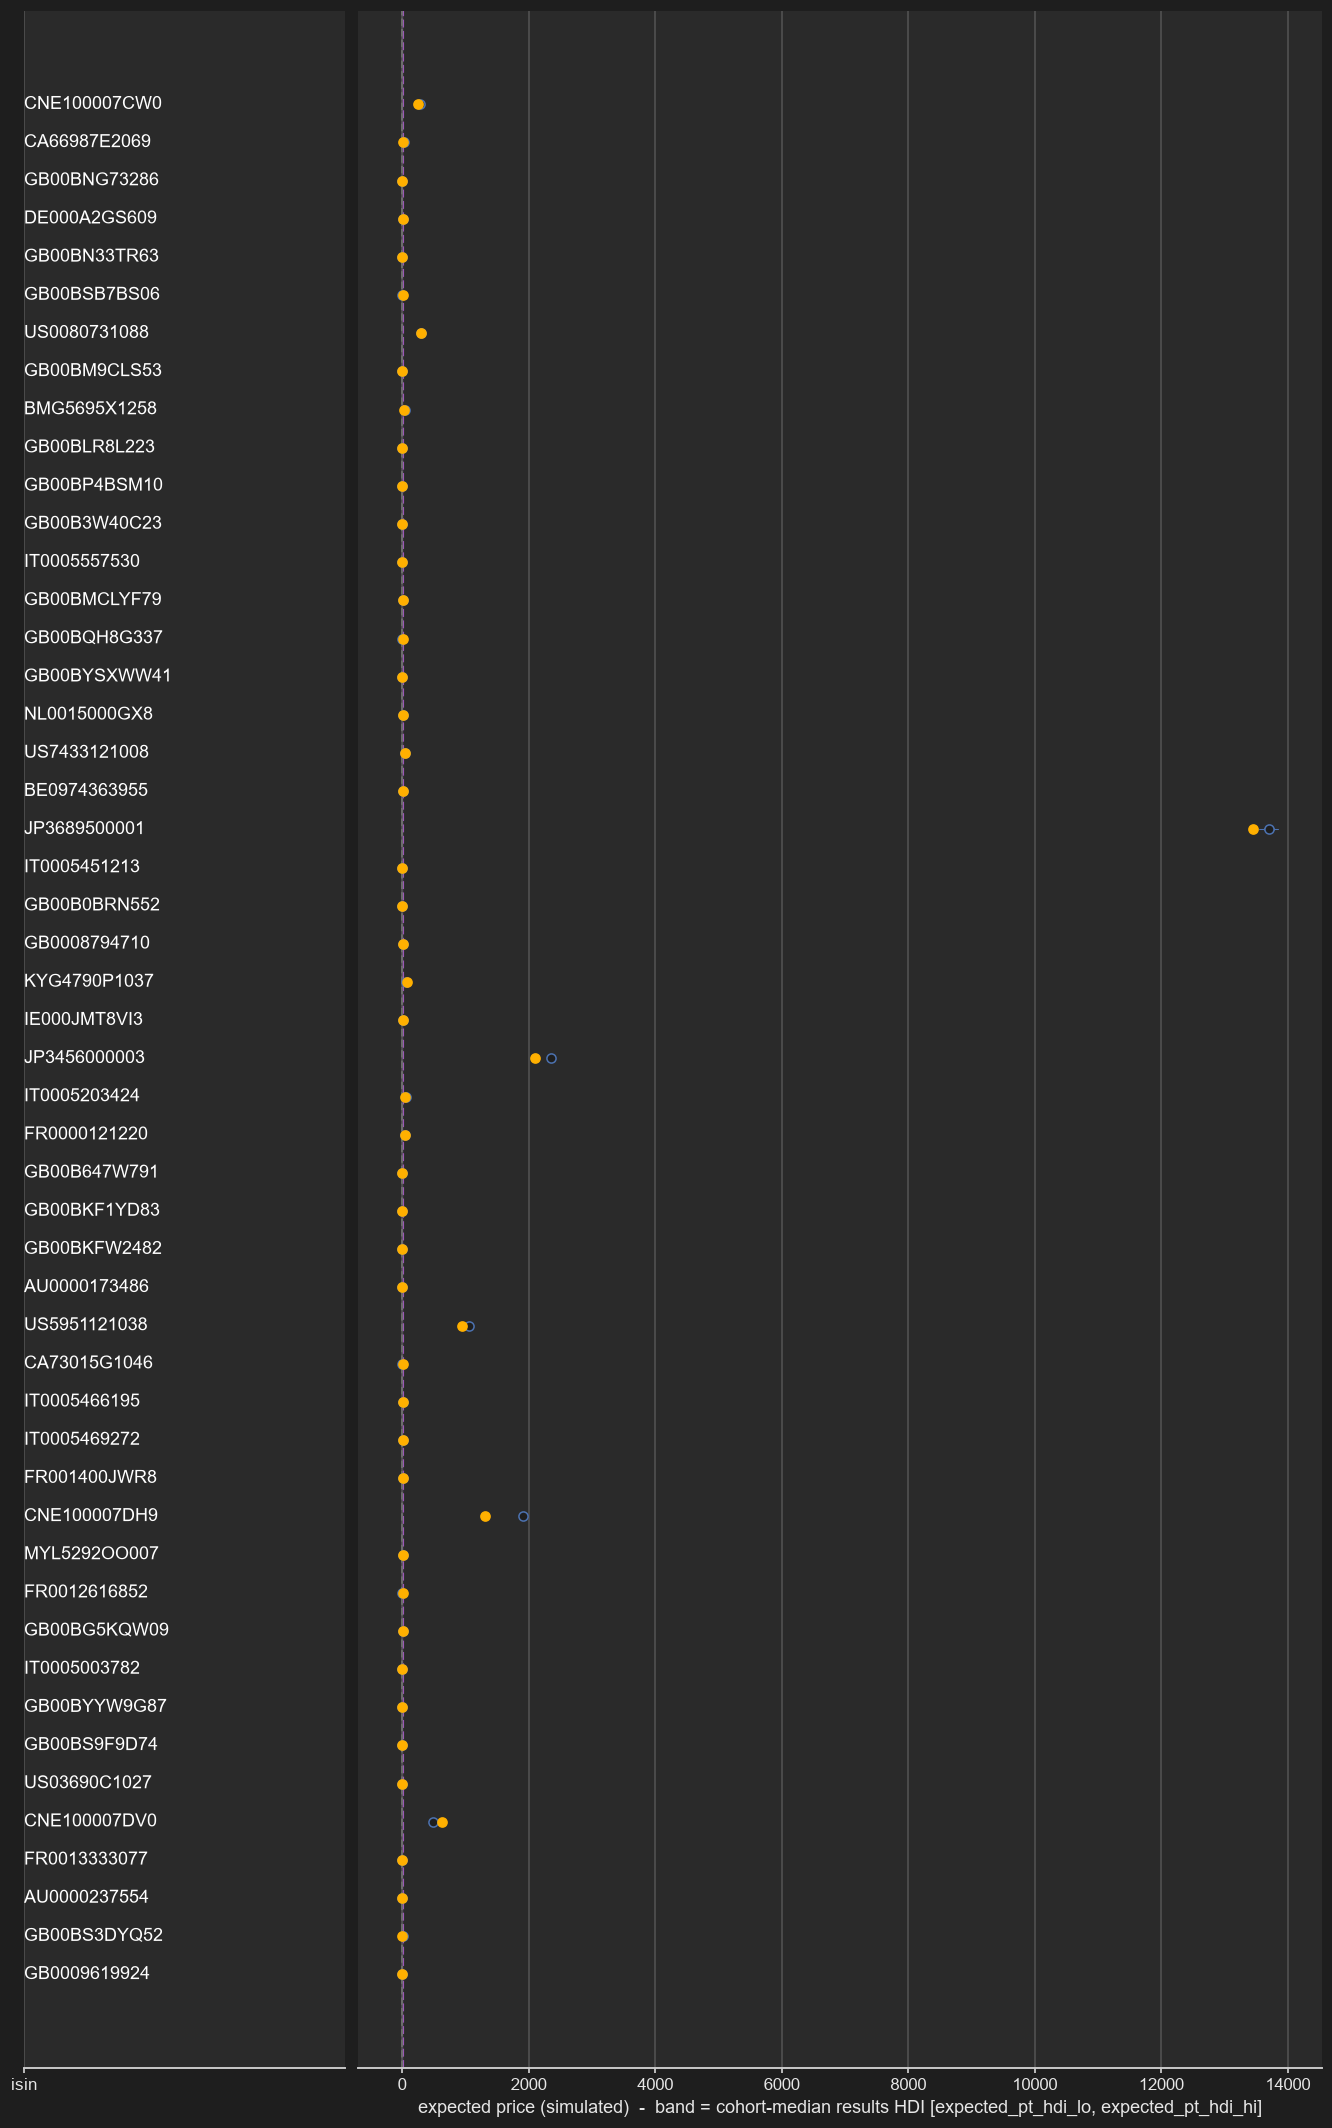

results-df cohort-median 94% HDI band: (5.48, 5.79);  median expected_pt = 5.63;  cohort last_price = 4.66.


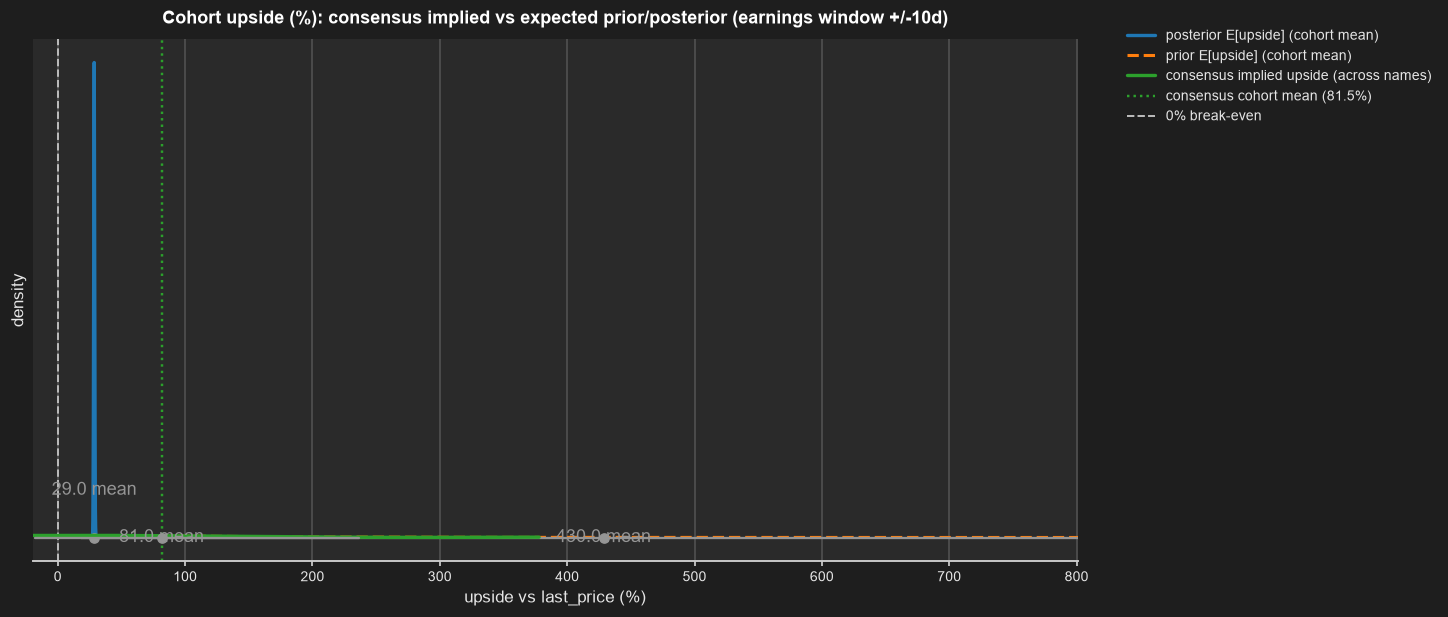

Consensus implied upside [feat_implied_upside (SSOT)]: cohort mean = 81.48% across 50 names.
Expected upside (cohort mean): prior = 428.53%, posterior = 28.61%;  P(posterior cohort upside > 0) = 100.0%;  P(posterior cohort upside > consensus mean) = 0.0%.


In [16]:
forest_ctx = run_granular_forest(idata, results, panel, screen, engine)
run_granular_further_views(prior_idata, panel, screen, forest_ctx)

## §14 — Comprehensive summary & actionable recommendations

`run_summary` consolidates the notebook into a decision-oriented read on the names
reporting within the **±10-day** earnings window, benchmarked against the broader
universe:

- **Cross-sectional** — earnings cohort vs the rest of the universe (names *not*
  reporting), on expected upside, share positive, credible-band width (uncertainty) and
  Kalman shrinkage vs raw consensus, read from the §10 `results` table.
- **Time-series** — the mingled cohort's reconstructed `*_ago` consensus trail (§12):
  oldest vs most-recent consensus, and the latest smoothed target's implied upside.
- **Distributional** — a posterior KDE of cohort-average vs universe-average expected
  upside with a 0 % break-even line.

`run_recommendations` (§14b) turns the posterior into risk-aware signals — read-only over
`idata`, the panel frame and `results`, reusing the §10 `compute_cvar_aware_book` so the
sizing matches the export exactly:

- **§1–§7 directional** — group- and name-level OVERWEIGHT / NEUTRAL / UNDERWEIGHT
  verdicts plus a band-width / coverage caution list.
- **§8 risk-adjusted** — reward per unit of *expected volatility* (the `feat_vol_*`
  term-structure; a separate portfolio-level risk budget, distinct from the panel's
  beta-based `risk_adj_return`), a forward Sharpe-like ranking that demotes
  high-upside / high-vol names.
- **§9 CVaR tails** — per-name expected shortfall (mean of the worst `ALPHA`-tail) of the
  upside draws, cross-checked against the Student-t Monte-Carlo 5 % return; with a low
  estimated `nu` these tails — not the means — drive sizing.
- **§10 CVaR-aware sizing** — a long book sized on the reward-to-CVaR (STARR) ratio with a
  per-name cap and a joint-draw portfolio expected shortfall, so no single fat-tailed name
  dominates the book's tail risk.

All blocks are guarded: the summary degrades to whatever upstream artifacts are present in
the kernel, so a partial read still prints when the DB-dependent sections were skipped.

Cross-sectional summary - expected price targets by group:


,n_names,median_upside_%,mean_upside_%,positive_upside_%,median_band_width_%,median_shrink_vs_consensus_%,median_n_analysts
group,,,,,,,
Earnings cohort (+/-10d),229,31.01,30.25,91.27,2.22,-7.09,4.0
Historical baseline (not reporting),6004,28.08,28.76,92.70,2.17,5.45,8.0
Full universe,6233,28.19,28.82,92.65,2.18,5.26,8.0



Earnings-cohort sector tilt:


,n,median_upside_pct
sector,,
Industrials,48,29.00
Information Technology,43,29.20
Consumer Discretionary,40,33.46
Health Care,32,30.06
Consumer Staples,17,31.66
Communication Services,15,36.03
Materials,15,28.28
Energy,13,36.58
Utilities,6,30.02



KEY INSIGHTS - recent earnings period vs historical data
- 229 names report within +/-10d. Median expected upside 31.0% vs 28.1% for non-reporting names (delta 2.9 pp).
- 91% of the cohort has positive expected upside; median credible band width 2.2% (universe 2.2%).
- Kalman-smoothed targets sit 7.1% below raw consensus (median) - shrinkage toward the hierarchical group mean.
- Highest expected upside: 3317 (109%), NG (107%), AURR (90%).
- Lowest / most downside : IQE (-84%), RPI (-36%), ALL (-29%).
- Historical target trail (2019-12-31 -> 2027-01-01): mingled cohort consensus rose 912.5%; latest Kalman-smoothed target implies 182.9% upside vs cohort last price.


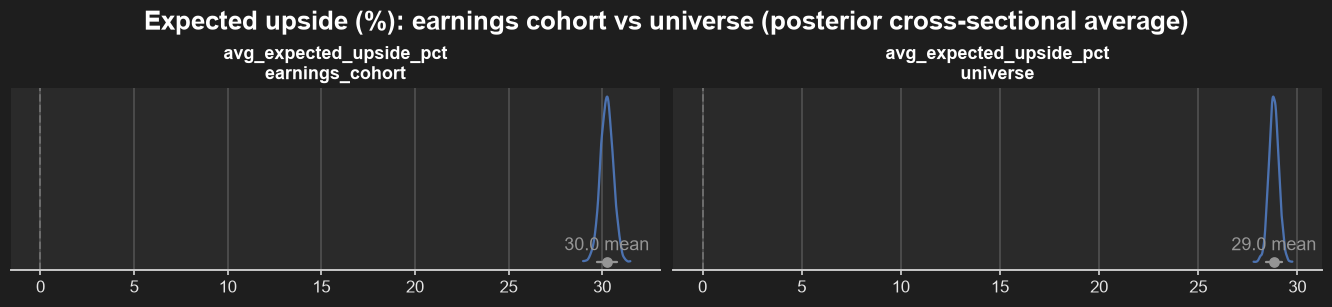

KALMAN PRICE-TARGET SCREEN - ACTIONABLE INVESTMENT RECOMMENDATIONS

1. POSTERIOR RELIABILITY    max R-hat=nan    divergences=1
   [!!]  Convergence concerns - treat signals as indicative only.

2. TAIL RISK    Student-t df (nu)=2.5  ->  heavy - analyst-target outliers are material; prefer CVaR-aware sizing.

3. UNIVERSE POSTURE    posterior-mean upside=28.82%    P(upside>0)=93%    names=6233
   Rule: OVERWEIGHT if group upside > universe+2pp and P(>0)>=60%; UNDERWEIGHT if < universe-2pp or P(>0)<=40%.

4.REGION SIGNALS  (5 groups)
    OVERWEIGHT  Latin America and Caribbea  upside= 45.74%  CI=[ 44.18, 47.23]  P(>0)=100%  n=226
       NEUTRAL  Europe                      upside= 30.03%  CI=[ 29.35, 30.72]  P(>0)=100%  n=1890
       NEUTRAL  Africa / Middle East        upside= 28.26%  CI=[ 26.75, 29.77]  P(>0)=100%  n=259
       NEUTRAL  Asia / Pacific              upside= 27.59%  CI=[ 26.92, 28.26]  P(>0)=100%  n=2050
       NEUTRAL  United States and Canada    upside= 26.90%  CI=[ 26.2

In [17]:
run_summary(results, screen, forest_ctx, mingled_ctx)
run_recommendations(idata, panel, results, screen, forest_ctx)

### §14.1 — Screen distribution & recommendation rankings (matplotlib)

In [ ]:
def plot_screen_overview(results_df, top_n=15):
    """

    Parameters
    ----------
    results_df
    top_n
    """
    eu = results_df["expected_upside_pct"].dropna() / 100.0
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Expected-upside distribution
    axes[0].hist(eu, bins=60, color="#4C72B0", edgecolor="black", alpha=0.8)
    axes[0].axvline(eu.median(), color="#C44E52", ls="--", lw=2,
                    label=f"median = {eu.median():.1%}")
    axes[0].axvline(0.0, color="grey", ls=":", lw=1.5, label="break-even")
    axes[0].set_title("Cross-sectional expected-upside distribution")
    axes[0].set_xlabel("Expected upside")
    axes[0].set_ylabel("ISIN count")
    axes[0].legend()

    # Top-N ranked recommendations with HDI error bars
    top = results_df.sort_values("expected_upside_pct", ascending=False).head(top_n).iloc[::-1]
    lbl = top["ticker"].fillna(top["isin"].str[:6])
    lo = (top["expected_pt_hdi_lo"] / top["last_price"] - 1.0).to_numpy()
    hi = (top["expected_pt_hdi_hi"] / top["last_price"] - 1.0).to_numpy()
    mid = top["expected_upside_pct"].to_numpy() / 100.0
    xerr = np.vstack([np.clip(mid - lo, 0, None), np.clip(hi - mid, 0, None)])

    axes[1].errorbar(mid, range(len(top)), xerr=xerr, fmt="o",
                     color="#55A868", ecolor="#8C8C8C", capsize=3)
    axes[1].axvline(0.0, color="grey", ls=":", lw=1.5)
    axes[1].set_yticks(range(len(top)))
    axes[1].set_yticklabels(lbl)
    axes[1].set_title(f"Top {top_n} expected upside (94% HDI band)")
    axes[1].set_xlabel("Expected upside")

    plt.show()


plot_screen_overview(results)

### §14.2 — Interactive risk/return screen (plotly)

In [ ]:
import plotly.express as px


def plot_risk_return_scatter(results_df, max_points=2500):
    """

    Parameters
    ----------
    results_df
    max_points
    """
    df = results_df.dropna(
        subset=["expected_upside_pct", "expected_pt_hdi_lo", "expected_pt_hdi_hi", "last_price"]
    ).copy()
    # `results` carries expected_upside_pct (percent); convert to a decimal fraction.
    df["expected_upside"] = df["expected_upside_pct"] / 100.0
    # HDI band width as a fraction of last price = posterior uncertainty proxy
    df["uncertainty"] = (df["expected_pt_hdi_hi"] - df["expected_pt_hdi_lo"]) / df["last_price"]
    df["label"] = df["ticker"].fillna(df["isin"].str[:6])
    if len(df) > max_points:
        df = df.nlargest(max_points, "expected_upside")

    fig = px.scatter(
        df,
        x="uncertainty",
        y="expected_upside",
        color="sector",
        size="last_price",
        size_max=22,
        hover_name="label",
        hover_data={"isin": True, "name": True, "industry": True, "expected_pt": ":.2f",
                    "last_price": ":.2f", "uncertainty": ":.2%", "sector": False},
        title="Expected upside vs posterior uncertainty (94% HDI width)",
        labels={"uncertainty": "Posterior uncertainty (HDI width / last price)",
                "expected_upside": "Expected upside"},
    )
    fig.add_hline(y=0.0, line_dash="dot", line_color="grey")
    fig.update_layout(template="plotly_dark", height=650, legend_title_text="Sector")
    fig.show()


plot_risk_return_scatter(results)

### §14.3 — Posterior forest of top candidates (arviz)

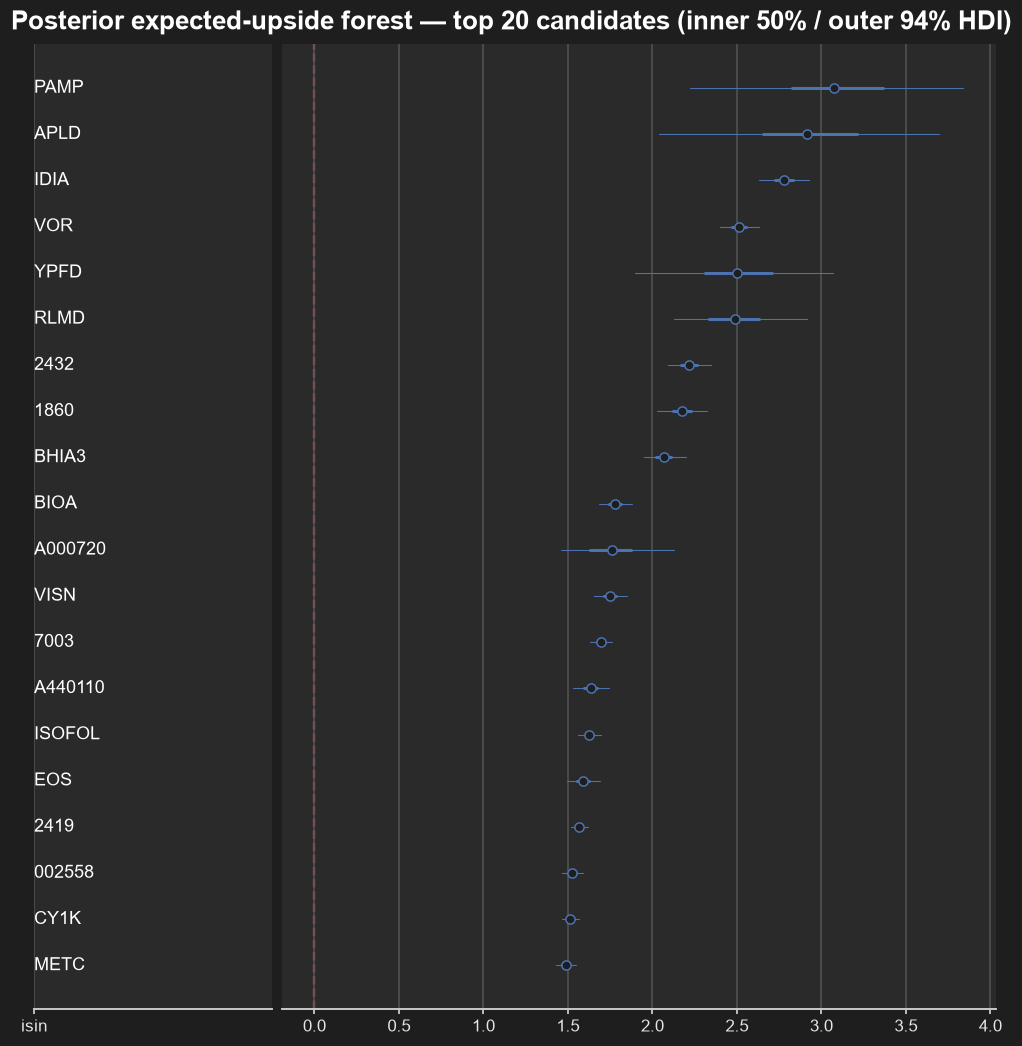

In [20]:
import matplotlib.pyplot as plt


def plot_top_candidate_forest(screen_ctx, results_df, top_n=20):
    """

    Parameters
    ----------
    screen_ctx
    results_df
    top_n

    Returns
    -------

    """
    # Rank by expected upside; drop names with no posterior screen value.
    top = (results_df.dropna(subset=["expected_upside_pct"])
           .sort_values("expected_upside_pct", ascending=False)
           .head(top_n))

    # screen.eu is (chain, draw, isin). Intersect with the posterior coord (preserving
    # the ranked order) so a name absent from the draws can't raise a sel KeyError.
    eu_isins = set(np.asarray(screen_ctx.eu["isin"].values).astype(str))
    top = top[top["isin"].astype(str).isin(eu_isins)]
    top_isins = top["isin"].astype(str).tolist()
    if not top_isins:
        print("No top candidates overlap the posterior draws — nothing to plot.")
        return
    eu = screen_ctx.eu.sel(isin=top_isins)

    # Ticker label with an ISIN-prefix fallback, built in ranked (top_isins) order.
    labels = [tk if isinstance(tk, str) and tk else str(iso)[:6]
              for iso, tk in zip(top["isin"], top["ticker"])]
    eu = eu.assign_coords(isin=labels)

    # arviz-plots 1.x expects a DataTree with a `posterior` group. Build it directly
    # from the existing DataArray rather than via azb.from_dict, which treats dict
    # *values* as nested {var: array} groups (a bare DataArray -> DataArray.items()).
    posterior = eu.rename("expected_upside").to_dataset(name="expected_upside")
    dt = DataTree.from_dict({"posterior": posterior})

    # 1.x renames hdi_prob -> ci_probs and *requires a two-element (inner, outer)
    # sequence*: plot_forest always indexes ci_probs[1], so a single-element list
    # raised IndexError. (0.5, 0.94) draws the inner 50% / outer 94% HDI. `labels`
    # and `figure_kwargs` mirror the module's canonical plot_forest call sites.
    figsize = (9.0, max(2.5, 0.42 * len(top_isins) + 1.0))
    pc = azp.plot_forest(
        dt,
        combined=True,
        ci_probs=(0.5, 0.94),
        labels=["isin"],
        backend="matplotlib",
        figure_kwargs={"figsize": figsize},
    )

    # 1.x returns a PlotCollection whose `plot` viz carries a `column` facet dim
    # (labels gutter + forest panel). Annotate only the forest column so the
    # break-even line isn't painted across the label gutter.
    forest_axes = pc.viz["plot"]
    if "column" in forest_axes.dims:
        forest_axes = forest_axes.sel(column="forest")
    for ax in np.atleast_1d(forest_axes.values).ravel():
        ax.axvline(0.0, color="#C44E52", ls="--", lw=1.5, zorder=0)

    pc.add_title(
        f"Posterior expected-upside forest — top {len(top_isins)} candidates "
        f"(inner 50% / outer 94% HDI)"
    )
    pc.show()


plot_top_candidate_forest(screen, results)


---
### Artifacts available at the top level

`kalman_df`, `roles`, `drift_features`, `panel`, `model`, `prior_idata`, `idata`,
`screen`, `results`, `kalman_results`, `single_ctx`, `mingled_ctx`, `forest_ctx`.

To run everything in one shot instead, call `kf.main(run_eda_section=True,
write_analytics=False, robust=True)`.